# 03 - Intensity-Duration-Frequency (IDF) Curve Analysis - DEMO VERSION

## DEMO LIMITATIONS
**This demo uses only 2 years of data (1990-1992) on a 50×50 grid subset.**

**IDF curves require 10-30+ years for statistical reliability, based on input data.**

**These outputs demonstrate METHODOLOGY ONLY - results are NOT scientifically valid.**

**For proper IDF analysis, see full domain results using 15 years of data. (04_Precip_periods_IDF_curves_final.ipynb)**


## Overview
Calculates IDF curves from WRF-BCC 15-minute precipitation data for metropolitan regions across CONUS. Processes multiple climate scenarios (historical and future) to quantify changes in extreme precipitation characteristics.

## Workflow

### 1. Data Loading
- Load WRF-BCC precipitation (AFWA_TOTPRECIP) for specified scenario/period
- Extract 7×7 grid cell domains (~26 km by 26 km) centered on target cities (or other specified size)
- Process in temporal batches to manage memory constraints

### 2. Annual Maxima Calculation
- Compute rolling precipitation sums for 8 durations (15min, 30min, 1hr, 2hr, 3hr, 6hr, 12hr, 24hr)
- Convert accumulations to intensity (mm/hr)
- Extract annual maximum intensity for each grid cell, duration, and hydrological year
- Handle batch boundaries with rollover to preserve continuous rolling windows
- Creat a larger sample - for the purposes of methods testing - from the smaller sample via duplicaiton

### 3. Gumbel Distribution Fitting
For each grid cell and duration:
- Fit Gumbel distribution to annual maxima using method of moments:
  - Scale parameter: β = (√6/π) × σ
  - Location parameter: μ = x̄ - 0.5772β
- Calculate intensities for return periods (2, 5, 10, 25, 50, 100 years)
- Quantify goodness-of-fit using R^2 on Gumbel probability plot (weibull plotting positions)

### 4. Uncertainty Quantification
- Bootstrap resampling (1000 iterations) of annual maxima
- Generate percentile confidence intervals for each return period

### 5. Metro-Scale Aggregation
- Calculate median intensity across all grid cells for each return period and duration
- Compute ensemble statistics (lower/upper bounds from bootstrap distributions)

### 6. Validation/ Output
- Validate IDF curves (e.g., monotonicity check, R^2 thresholds)
- Export tables
- Generate diagnostic plots (e.g., IDF curves), these are just for sanity check, not for publication



In [1]:
from __future__ import annotations

# OS packages
import os
import glob
import time
import gc
import logging
import sys
from datetime import datetime, timedelta

# Data Packages
import numpy as np
import xarray as xr
from scipy import stats
import pandas as pd

# Distributed computing
import dask
from dask.diagnostics import ProgressBar
from distributed import Client

# Plotting Packages
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.offsetbox import AnchoredText

# Display inline plots in notebook
%matplotlib inline

In [2]:
# Analysis Configuration

# ======= ANALYSIS CONFIGURATION =======
# DEMO VERSION: Reduced scope

# Select scenario to process
SCENARIO = "HIST"  # DEMO: Only HIST in the demo data (vs 5 scenarios in full analysis)

# Define date ranges based on scenario
# DEMO: Only 2 water years vs 15 in full analysis
HYDRO_YEAR_START = 1990
HYDRO_YEAR_END = 1992  # Only 1990-1991 and 1991-1992

# Generate list of years to process
YEARS = list(range(HYDRO_YEAR_START, HYDRO_YEAR_END))
YEAR_RANGE_STR = f"{HYDRO_YEAR_START}-{HYDRO_YEAR_END}"

# ======== DATA PARAMETERS ========
# Define durations to analyze (in number of 15-minute timesteps)
# 15min=1, 30min=2, 1hr=4, 2hr=8, 3hr=12, 6hr=24, 12hr=48, 24hr=96
#DURATIONS = [1, 2, 4, 8, 12, 24, 48, 96]
DURATIONS = [1, 4, 96]

# Define return periods for IDF curves (in years)
RETURN_PERIODS = [2, 5, 10, 25, 50, 100]

# ====== CITY REGIONS =======
# DEMO VERSION: Define city regions within 50×50 demo domain
# Note: Using approximate lat/lon for demo subset region
CITY_REGIONS = [
     {"name": "demo_north", "city_name": "Demo North", "coords": [38.125, -99.0], "size": 7},
     {"name": "demo_center", "city_name": "Demo Center", "coords": [37.5, -98.5], "size": 7},
     {"name": "demo_south", "city_name": "Demo South", "coords": [37.375, -98.0], "size": 7}
]

# For visualization, select a default city
DEFAULT_CITY = "demo_center"

# Grid file for coordinate to index conversion
# DEMO: Using demo subset grid file
GRID_FILE = "./data/demo/geo_em_d01_demo.nc"

# ======= FILE PATHS =======
# Base path for output files
OUTPUT_BASE = "./output/demo/idf"

# Version tag for file naming (should we need to re-run)
VERSION_TAG = "demo_v1"

# Data paths based on scenario
# DEMO: Using demo precipitation files
DATA_PATH = "./data/demo/precipitation"

# ======= COMPUTATIONAL SETTINGS ========
# DEMO: Reduced for laptop execution
# Batch size for file processing (may need to adjust based on available memory)
BATCH_SIZE = 30  # Reduced from 60 for demo

# Force recalculation even if files exist
FORCE_RECALCULATION = False

# Create output dirs
OUTPUT_DIR = f"{OUTPUT_BASE}/{SCENARIO}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Set up logging
LOG_DIR = f"{OUTPUT_BASE}/logs"
os.makedirs(LOG_DIR, exist_ok=True)
LOG_FILE = f"{LOG_DIR}/idf_processing_{SCENARIO}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.log"

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler(LOG_FILE, mode='a'),
        logging.StreamHandler(sys.stdout)
    ]
)

logger = logging.getLogger('idf_processing')
logger.info(f"Starting IDF curve analysis for {SCENARIO} scenario - DEMO VERSION")
logger.info(f"Processing hydrological years {YEAR_RANGE_STR} - ONLY 2 YEARS")
logger.info(f"WARNING: Results NOT statistically valid - demonstration only")


2026-02-14 04:28:42,285 - INFO - Starting IDF curve analysis for HIST scenario - DEMO VERSION
2026-02-14 04:28:42,288 - INFO - Processing hydrological years 1990-1992 - ONLY 2 YEARS
2026-02-14 04:28:42,290 - INFO - WARNING: Results NOT statistically valid - demonstration only


In [3]:
# Dask Setup for Distributed Computing

# Configure Dask Client for parallel processing across cores for I/O bound task (great canidate for GPU acceleration if scope is expanded)
# DEMO: Reduced resources for laptop vs on server (even with server settings this took dozens of hours on TRITON)
N_WORKERS = 2  # Reduced from 8
THREADS_PER_WORKER = 2  # Reduced from 4
MEMORY_LIMIT = "4GB"  # Reduced from 16GB

# Create client
try:
    client = Client(n_workers=N_WORKERS, 
                    threads_per_worker=THREADS_PER_WORKER, 
                    memory_limit=MEMORY_LIMIT)
    logger.info(f"Dask client initialized with {N_WORKERS} workers, {THREADS_PER_WORKER} threads per worker")
    logger.info(f"Client dashboard: {client.dashboard_link}")
    client
except Exception as e:
    logger.error(f"Error setting up Dask client: {str(e)}")
    raise

2026-02-14 04:28:48,126 - INFO - Dask client initialized with 2 workers, 2 threads per worker
2026-02-14 04:28:48,132 - INFO - Client dashboard: http://127.0.0.1:8787/status


In [4]:
# Helper Functions

def filter_valid_file_paths(file_paths):
    """
    Filter out files that don't exist.
    
    Parameters:
    -----------
    file_paths : list
        List of file paths to check
    
    Returns:
    --------
    list : List of valid file paths that exist on disk
    """
    valid_paths = [path for path in file_paths if os.path.exists(path)]
    
    # Log if any files were missing
    if len(valid_paths) < len(file_paths):
        missing = len(file_paths) - len(valid_paths)
        logger.warning(f"{missing} file(s) not found out of {len(file_paths)} requested")
    
    return valid_paths


def get_files_in_date_range(path, date_range, hours_offset, scenario):
    """
    Get files within a specified date range, handling water year transitions.
    
    DEMO VERSION: Simplified file structure - all files in single directory with _demo.nc suffix.
    
    Parameters:
    -----------
    path : str
        Base directory path for precipitation data
    date_range : str
        Date range in format "YYYY-MM-DD to YYYY-MM-DD"
    hours_offset : int
        Hours to offset end date (typically -1 to handle exclusive end time)
    scenario : str
        Climate scenario name to determine file path format
    
    Returns:
    --------
    list : List of file paths within the date range
    """
    date_format = "%Y-%m-%d"
    
    # Parse the date range string
    start_date_str, end_date_str = date_range.split(" to ")
    start_date = datetime.strptime(start_date_str, date_format)
    end_date = datetime.strptime(end_date_str, date_format)
    
    # Apply offset to end date
    hours_offset += 24  # account for end of day
    end_date += timedelta(hours=hours_offset)
    
    # Initialize file list
    files = []
    
    # Iterate over each date
    current_date = start_date
    while current_date <= end_date:
        year = current_date.year
        month = current_date.month
        day = current_date.day
        
        # DEMO: Simplified path structure - no year subdirectories
        fpath = f"{path}/AFWA_TOTPRECIP_{year}-{month:02d}-{day:02d}_demo.nc"
        
        files.append(fpath)
        current_date += timedelta(days=1)
    
    # Log the number of files found
    valid_files = filter_valid_file_paths(files)
    logger.info(f"Found {len(valid_files)} valid files out of {len(files)} requested")
    
    # Return only valid files
    return valid_files


def find_sample_file(scenario, year):
    """
    Find a sample precipitation file for the specified scenario and year.
    
    DEMO VERSION: Simplified file structure.
    
    Parameters:
    -----------
    scenario : str
        Climate scenario name
    year : int
        Year to find sample file for
    
    Returns:
    --------
    str : Path to a sample file, or None if not found
    """
    logger.info(f"Looking for sample file for {scenario}, year {year}")
    
    # DEMO: Try standard demo path
    sample_path = f"{DATA_PATH}/AFWA_TOTPRECIP_{year}-10-01_demo.nc"
    if os.path.exists(sample_path):
        logger.info(f"Found sample file at {sample_path}")
        return sample_path
    
    # Try looking in the first month of the water year (October)
    for day in range(1, 32):
        alt_path = f"{DATA_PATH}/AFWA_TOTPRECIP_{year}-10-{day:02d}_demo.nc"
        if os.path.exists(alt_path):
            logger.info(f"Found sample file at {alt_path}")
            return alt_path
    
    # Try other months in the water year
    for month in range(11, 13):  # Nov-Dec
        for day in range(1, 29, 7):  # Check days 1, 8, 15, 22
            alt_path = f"{DATA_PATH}/AFWA_TOTPRECIP_{year}-{month:02d}-{day:02d}_demo.nc"
            if os.path.exists(alt_path):
                logger.info(f"Found sample file at {alt_path}")
                return alt_path
    
    # Try months in the next calendar year
    for month in range(1, 10):  # Jan-Sep
        for day in range(1, 29, 7):  # Check days 1, 8, 15, 22
            alt_path = f"{DATA_PATH}/AFWA_TOTPRECIP_{year+1}-{month:02d}-{day:02d}_demo.nc"
            if os.path.exists(alt_path):
                logger.info(f"Found sample file at {alt_path}")
                return alt_path
    
    # Log that no file was found
    logger.error(f"No sample file found for {scenario}, year {year}")
    return None


def coords_to_indices(grid_file, target_lat, target_lon):
    """
    Convert latitude/longitude coordinates to grid indices.
    
    DEMO VERSION: Works with demo grid file (50×50 subset).
    
    Parameters:
    -----------
    grid_file : str
        Path to WRF geogrid file containing XLAT_M and XLONG_M
    target_lat : float
        Target latitude
    target_lon : float
        Target longitude
    
    Returns:
    --------
    tuple : (lat_idx, lon_idx) indices of nearest grid cell
    """
    # Load grid file
    grid = xr.open_dataset(grid_file, engine="netcdf4")
    
    # Get lat/lon arrays (assuming first time step)
    lats = grid.XLAT_M[0].values
    lons = grid.XLONG_M[0].values
    
    # Calculate distance to all grid points
    lat_diff = lats - target_lat
    lon_diff = lons - target_lon
    
    # Calculate squared distance (no need for sqrt since we just want minimum)
    distance_sq = lat_diff**2 + lon_diff**2
    
    # Find indices of minimum distance
    lat_idx, lon_idx = np.unravel_index(np.argmin(distance_sq), distance_sq.shape)
    
    # Get actual coordinates of selected grid cell
    actual_lat = lats[lat_idx, lon_idx]
    actual_lon = lons[lat_idx, lon_idx]
    
    logger.info(f"Target coordinates: ({target_lat:.4f}, {target_lon:.4f})")
    logger.info(f"Nearest grid cell: ({actual_lat:.4f}, {actual_lon:.4f}) at indices ({lat_idx}, {lon_idx})")
    
    grid.close()
    
    return int(lat_idx), int(lon_idx)


def get_grid_corners(grid_file, lat_idx, lon_idx, size):
    """
    Get the actual lat/lon coordinates of city region corners for plotting.
    
    DEMO VERSION: Works with demo grid file.
    
    Parameters:
    -----------
    grid_file : str
        Path to WRF geogrid file containing XLAT_M and XLONG_M
    lat_idx : int
        Center latitude index
    lon_idx : int
        Center longitude index
    size : int
        Size of the region in grid cells
    
    Returns:
    --------
    dict : Dictionary with corner coordinates and center info
    """
    # Load grid file
    grid = xr.open_dataset(grid_file, engine="netcdf4")
    
    # Get lat/lon arrays (assuming first time step)
    lats = grid.XLAT_M[0].values
    lons = grid.XLONG_M[0].values
    
    # Calculate bounds
    half_size = size // 2
    lat_start = max(0, lat_idx - half_size)
    lat_end = min(lats.shape[0], lat_idx + half_size + (size % 2))
    lon_start = max(0, lon_idx - half_size)
    lon_end = min(lats.shape[1], lon_idx + half_size + (size % 2))
    
    # Get corner coordinates
    corners = {
        'lat_min': float(lats[lat_start, :].min()),
        'lat_max': float(lats[lat_end-1, :].max()),
        'lon_min': float(lons[:, lon_start].min()),
        'lon_max': float(lons[:, lon_end-1].max()),
        'center_lat': float(lats[lat_idx, lon_idx]),
        'center_lon': float(lons[lat_idx, lon_idx]),
        'lat_start': lat_start,
        'lat_end': lat_end,
        'lon_start': lon_start,
        'lon_end': lon_end
    }
    
    grid.close()
    
    return corners


def get_city_region(ds, center_lat_idx=None, center_lon_idx=None, size=15):
    """
    Define bounds for a square city region centered at specified indices.
    
    DEMO VERSION: Adjusted default size to 15 for demo domain.
    
    Parameters:
    -----------
    ds : xarray.Dataset
        Dataset containing precipitation data
    center_lat_idx : int, optional
        Center latitude index, defaults to middle of domain
    center_lon_idx : int, optional
        Center longitude index, defaults to middle of domain
    size : int
        Size of the city region in grid cells (produces size×size region)
    
    Returns:
    --------
    dict : Dictionary with slices for selecting the city region
    """
    # Detect dimension names
    if 'south_north' in ds.dims:
        lat_dim = 'south_north'
    elif 'lat' in ds.dims:
        lat_dim = 'lat'
    elif 'latitude' in ds.dims:
        lat_dim = 'latitude'
    else:
        lat_dim = list(ds.dims)[1]  # Assume lat is second dimension
        
    if 'west_east' in ds.dims:
        lon_dim = 'west_east'
    elif 'lon' in ds.dims:
        lon_dim = 'lon'
    elif 'longitude' in ds.dims:
        lon_dim = 'longitude'
    else:
        lon_dim = list(ds.dims)[2]  # Assume lon is third dimension
    
    # Get dimension sizes
    lat_size = ds.dims[lat_dim]
    lon_size = ds.dims[lon_dim]
    
    # Set center indices if not provided
    if center_lat_idx is None:
        center_lat_idx = lat_size // 2
    if center_lon_idx is None:
        center_lon_idx = lon_size // 2
    
    # Calculate bounds
    half_size = size // 2
    lat_start = max(0, center_lat_idx - half_size)
    lat_end = min(lat_size, center_lat_idx + half_size + (size % 2))  # Add 1 if size is odd
    lon_start = max(0, center_lon_idx - half_size)
    lon_end = min(lon_size, center_lon_idx + half_size + (size % 2))
    
    # Create region dictionary with slices
    region = {
        lat_dim: slice(lat_start, lat_end),
        lon_dim: slice(lon_start, lon_end)
    }
    
    # Log region information
    logger.info(f"City region defined: {lat_dim}[{lat_start}:{lat_end}], {lon_dim}[{lon_start}:{lon_end}]")
    logger.info(f"Region size: {lat_end-lat_start}×{lon_end-lon_start} cells")
    logger.info(f"Approx physical size: {(lat_end-lat_start)*3.75:.1f}×{(lon_end-lon_start)*3.75:.1f} km")
    
    return region


def plot_city_region(ds, city_region):
    """
    Plot the city region to visualize its location within the full domain. This is just a sanity check - NOTE: index based, not Lat/Lon
    
    DEMO VERSION: Works with demo domain (50×50).
    
    Parameters:
    -----------
    ds : xarray.Dataset
        Dataset containing precipitation data
    city_region : dict
        Dictionary with slices for the city region
    
    Returns:
    --------
    matplotlib.figure.Figure : Figure showing the city region (index based, not lat/lon)
    """
    # Get dimension names and indices
    lat_dim = list(city_region.keys())[0]
    lon_dim = list(city_region.keys())[1]
    
    lat_start = city_region[lat_dim].start
    lat_end = city_region[lat_dim].stop
    lon_start = city_region[lon_dim].start
    lon_end = city_region[lon_dim].stop
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot domain outline
    full_width = ds.dims[lon_dim]
    full_height = ds.dims[lat_dim]
    ax.plot([0, full_width, full_width, 0, 0], 
            [0, 0, full_height, full_height, 0], 
            'k-', linewidth=1, alpha=0.5)
    
    # Plot city region
    rect = patches.Rectangle(
        (lon_start, lat_start), 
        lon_end - lon_start, 
        lat_end - lat_start,
        linewidth=2, edgecolor='r', facecolor='none'
    )
    ax.add_patch(rect)
    
    # Set axis limits with some padding
    padding = max(full_width, full_height) * 0.05
    ax.set_xlim(-padding, full_width + padding)
    ax.set_ylim(-padding, full_height + padding)
    
    # Add labels and title
    ax.set_xlabel(f'{lon_dim} Index', fontsize=12)
    ax.set_ylabel(f'{lat_dim} Index', fontsize=12)
    ax.set_title(f'City Region for IDF Analysis - {SCENARIO} - DEMO', fontsize=14)
    
    # Add region info
    region_info = (f"City Region:\n"
                   f"{lat_dim} indices: {lat_start} to {lat_end}\n"
                   f"{lon_dim} indices: {lon_start} to {lon_end}\n"
                   f"Size: {lat_end-lat_start}×{lon_end-lon_start} cells\n"
                   f"Approx. size: {(lat_end-lat_start)*3.75:.1f}×{(lon_end-lon_start)*3.75:.1f} km")
    at = AnchoredText(region_info, loc='lower left', prop=dict(size=10), frameon=True)
    at.patch.set_boxstyle("round,pad=0.3,rounding_size=0.2")
    ax.add_artist(at)
    
    ax.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    return fig



2026-02-14 04:28:48,378 - INFO - Testing get_files_in_date_range function
2026-02-14 04:28:48,439 - INFO - Found 3 valid files out of 3 requested
2026-02-14 04:28:48,442 - INFO - Found 3 files for date range 1990-10-01 to 1990-10-03
2026-02-14 04:28:48,447 - INFO - First file: AFWA_TOTPRECIP_1990-10-01_demo.nc
2026-02-14 04:28:48,449 - INFO - Last file: AFWA_TOTPRECIP_1990-10-03_demo.nc
2026-02-14 04:28:48,453 - INFO - Testing city region definition
2026-02-14 04:28:48,456 - INFO - Looking for sample file for HIST, year 1990
2026-02-14 04:28:48,458 - INFO - Found sample file at ./data/demo/precipitation/AFWA_TOTPRECIP_1990-10-01_demo.nc
2026-02-14 04:28:49,316 - INFO - Opened sample file: ./data/demo/precipitation/AFWA_TOTPRECIP_1990-10-01_demo.nc
2026-02-14 04:28:49,319 - INFO - Testing city region for demo_north
2026-02-14 04:28:49,509 - INFO - Target coordinates: (38.1250, -99.0000)
2026-02-14 04:28:49,511 - INFO - Nearest grid cell: (38.1193, -99.0006) at indices (38, 14)
2026-02-1

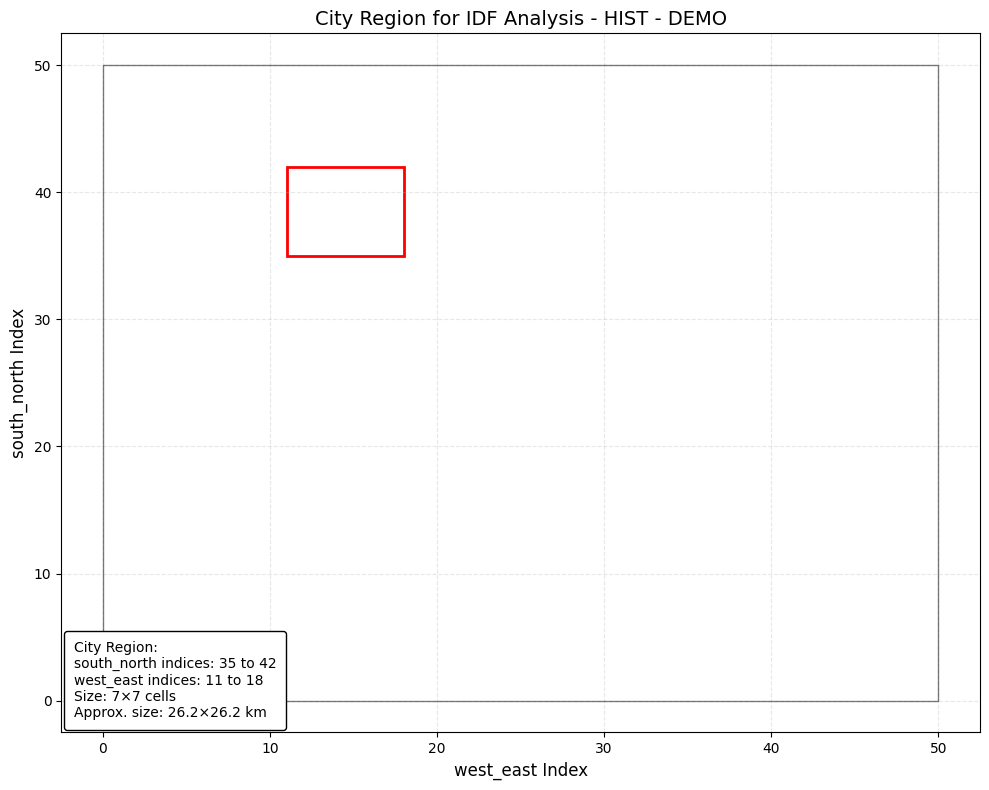

2026-02-14 04:28:51,225 - INFO - Testing city region for demo_center
2026-02-14 04:28:51,331 - INFO - Target coordinates: (37.5000, -98.5000)
2026-02-14 04:28:51,333 - INFO - Nearest grid cell: (37.4837, -98.5200) at indices (19, 25)
2026-02-14 04:28:51,339 - INFO - City region defined: south_north[16:23], west_east[22:29]
2026-02-14 04:28:51,341 - INFO - Region size: 7×7 cells
2026-02-14 04:28:51,342 - INFO - Approx physical size: 26.2×26.2 km
2026-02-14 04:28:53,033 - INFO - Saved city region plot to ./output/demo/idf/HIST/demo_center_region_HIST.png


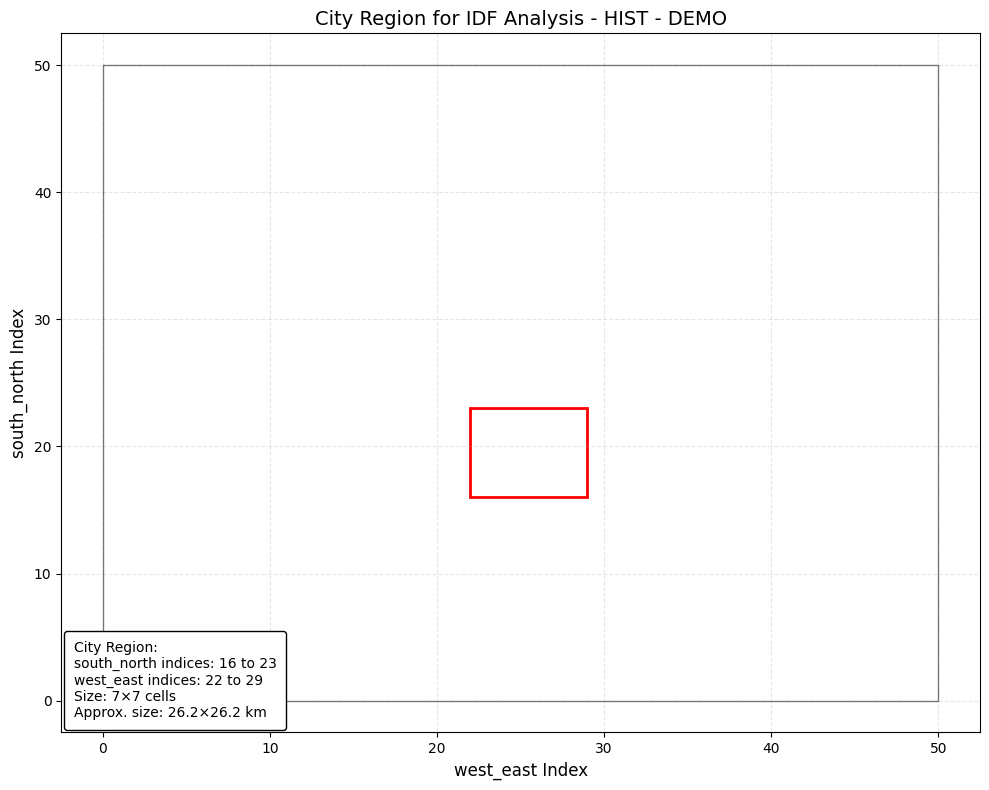

2026-02-14 04:28:53,375 - INFO - Testing city region for demo_south
2026-02-14 04:28:53,611 - INFO - Target coordinates: (37.3750, -98.0000)
2026-02-14 04:28:53,615 - INFO - Nearest grid cell: (37.3859, -98.0093) at indices (16, 37)
2026-02-14 04:28:53,626 - INFO - City region defined: south_north[13:20], west_east[34:41]
2026-02-14 04:28:53,629 - INFO - Region size: 7×7 cells
2026-02-14 04:28:53,632 - INFO - Approx physical size: 26.2×26.2 km
2026-02-14 04:28:54,818 - INFO - Saved city region plot to ./output/demo/idf/HIST/demo_south_region_HIST.png


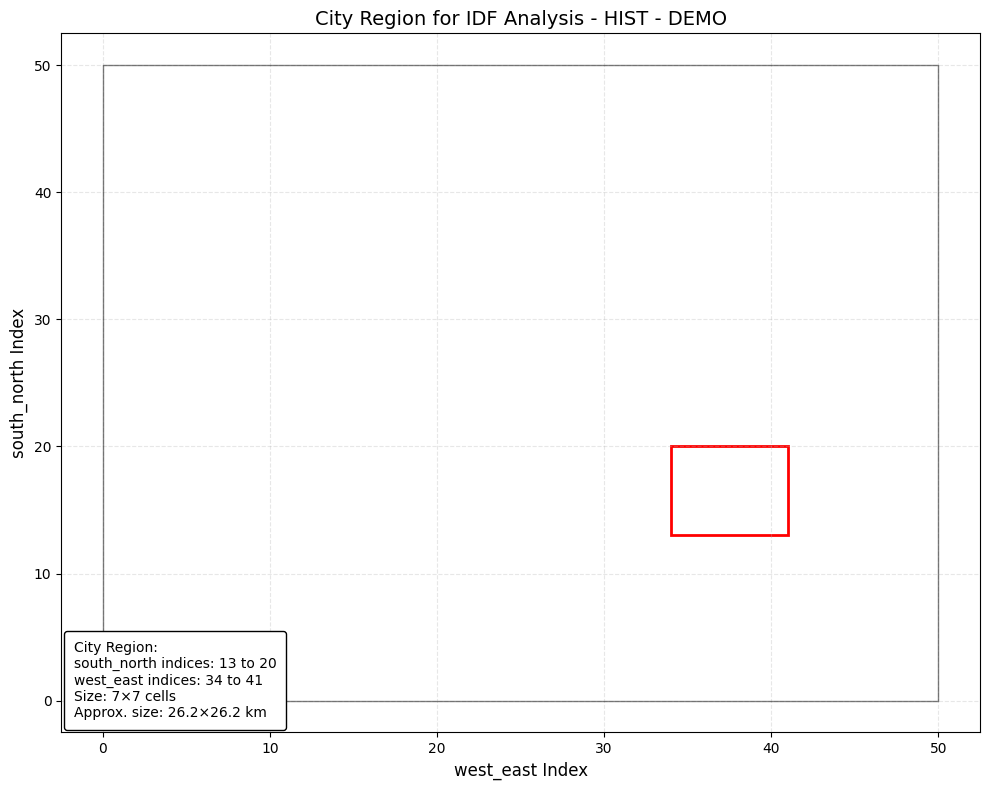

2026-02-14 04:28:55,331 - INFO - All helper function tests passed
Helper functions tests passed


In [5]:
# Test Helper Functions

# Test file path generation for a water year
def test_get_files_in_date_range():
    """Test function to verify file path generation works correctly"""
    logger.info("Testing get_files_in_date_range function")
    
    # Test for a small date range (3 days)
    test_range = f"{HYDRO_YEAR_START}-10-01 to {HYDRO_YEAR_START}-10-03"
    files = get_files_in_date_range(DATA_PATH, test_range, -1, SCENARIO)
    
    # Log results
    logger.info(f"Found {len(files)} files for date range {test_range}")
    if len(files) > 0:
        logger.info(f"First file: {os.path.basename(files[0])}")
        logger.info(f"Last file: {os.path.basename(files[-1])}")
    else:
        logger.warning("No files found for test date range")
    
    return files


# Test city region definition
def test_city_region():
    """Test function to verify city region definition and visualization"""
    logger.info("Testing city region definition")
    
    # Get a sample file
    sample_file = find_sample_file(SCENARIO, HYDRO_YEAR_START)
    
    if sample_file is None:
        logger.error("Cannot test city region without a sample file")
        return None
    
    # Open sample file
    try:
        sample_ds = xr.open_dataset(sample_file)
        logger.info(f"Opened sample file: {sample_file}")
        
        # Test for each city region
        for city in CITY_REGIONS:
            city_name = city["name"]
            coords = city["coords"]
            size = city["size"]
            
            logger.info(f"Testing city region for {city_name}")
            
            # Convert coordinates to indices
            lat_idx, lon_idx = coords_to_indices(GRID_FILE, coords[0], coords[1])
            
            # Define city region
            region = get_city_region(sample_ds, 
                                    center_lat_idx=lat_idx, 
                                    center_lon_idx=lon_idx, 
                                    size=size)
            
            # Create plot
            fig = plot_city_region(sample_ds, region)
            
            # Save plot
            plot_path = f"{OUTPUT_DIR}/{city_name}_region_{SCENARIO}.png"
            fig.savefig(plot_path, dpi=300, bbox_inches='tight')
            logger.info(f"Saved city region plot to {plot_path}")
            
            # Show plot
            plt.show()
        
        # Close dataset
        sample_ds.close()
        
        return True
    except Exception as e:
        logger.error(f"Error testing city region: {str(e)}")
        return None


# Run tests
test_files = test_get_files_in_date_range()
test_regions = test_city_region()

# Summary of test results
if len(test_files) > 0 and test_regions:
    logger.info("All helper function tests passed")
    print("Helper functions tests passed")
else:
    logger.error("One or more helper function tests failed")
    print("Helper function tests failed")

In [22]:
# Core Function for Annual Maximum Calculation with Batch Processing

def calculate_annual_max_for_durations(scenario, year, durations, city_regions):
    """
    Calculate annual maximum precipitation intensities for various durations for multiple city regions,
    using memory-efficient batch processing with proper handling of rolling windows across batch boundaries.
    
    DEMO VERSION: Adapted for simplified demo file structure.
    
    Parameters:
    -----------
    scenario : str
        Scenario name (e.g., "HIST", "MID4p5")
    year : int
        Starting year for the water year
    durations : list
        List of durations in number of 15-minute intervals
    city_regions : list
        List of dictionaries with city region information
    
    Returns:
    --------
    dict : Dictionary of city names to xarray.Dataset with annual maximum intensities
    """
    start_time = time.time()
    
    # Define date range for water year
    hours_offset = -1
    date_start = f'{year}-10-01'
    date_end = f'{year+1}-09-30'
    year_range = f'{year}-{year+1}'
    logger.info(f"Processing year range: {year_range}")
    
    # Get data path based on scenario
    data_path = DATA_PATH
    
    # Get files in date range
    files = get_files_in_date_range(data_path, f'{date_start} to {date_end}', hours_offset, scenario)
    files.sort()
    logger.info(f'Number of files: {len(files)}')
    
    if len(files) == 0:
        logger.error(f"No files found for {year_range}")
        return {}
    
    # Calculate max days required for the longest duration
    max_duration_in_days = max(durations) * 15 / (60 * 24)  # Convert from 15-min intervals to days
    rollover_days = int(np.ceil(max_duration_in_days))
    logger.info(f"Maximum duration: {max(durations)} time steps, requires {rollover_days} days of rollover data")
    
    # Initialize a dictionary to store dataset for each city
    city_datasets = {}
    
    # Initialize a dictionary to store maximum intensities for each city and duration
    max_intensities = {}
    for city_region in city_regions:
        city_name = city_region["name"]
        max_intensities[city_name] = {}
        
        for d in durations:
            # Convert duration to hours for naming
            hours = d * 15 / 60
            if hours < 1:
                duration_name = f"{int(hours * 60)}min"
            else:
                duration_name = f"{int(hours)}hr"
            max_intensities[city_name][duration_name] = None
    
    # Process files in batches to save memory
    batch_size = BATCH_SIZE
    
    # Initialize variables for batch processing
    prev_batch_data = {}  # Dictionary to store rollover data for each city
    rollover_steps = None  # Will be determined dynamically
    
    # Process each batch with overlapping files from the end of the previous batch
    for batch_start_idx in range(0, len(files), batch_size):
        batch_end_idx = min(batch_start_idx + batch_size, len(files))
        logger.info(f"Processing batch: files {batch_start_idx} to {batch_end_idx-1}")
        
        # Determine batch files
        batch_files = files[batch_start_idx:batch_end_idx]
        
        try:
            # Load batch files
            ds_batch = xr.open_mfdataset(batch_files, chunks='auto', combine='by_coords', engine='netcdf4')
            
            # Process each city region
            for city_region_info in city_regions:
                city_name = city_region_info["name"]
                indices = city_region_info.get("indices", None)
                coords = city_region_info["coords"]
                size = city_region_info["size"]
                
                logger.info(f"Processing {city_name} for batch {batch_start_idx//batch_size + 1}")
                
                # Convert coordinates to indices if not already done
                if indices is None or batch_start_idx == 0:
                    lat_idx, lon_idx = coords_to_indices(GRID_FILE, coords[0], coords[1])
                    city_region_info["indices"] = [lat_idx, lon_idx]
                else:
                    lat_idx, lon_idx = indices
                
                # Define city region
                city_region = get_city_region(ds_batch, 
                                            center_lat_idx=lat_idx, 
                                            center_lon_idx=lon_idx, 
                                            size=size)
                
                # Apply city region filter
                ds_city = ds_batch.isel(**city_region)
                
                # Check if we have rollover data from previous batch for this city
                if city_name in prev_batch_data and prev_batch_data[city_name] is not None:
                    logger.info(f"Including rollover data from previous batch for {city_name}")
                    # Concatenate with previous batch data along time dimension
                    ds_city_with_rollover = xr.concat([prev_batch_data[city_name], ds_city], dim="Time")
                else:
                    # First batch, just use current data
                    ds_city_with_rollover = ds_city
                
                # Dynamically determine steps per day if needed
                if rollover_steps is None and len(ds_city_with_rollover.Time) > 0:
                    # Get the first 2 days of data to determine steps per day
                    try:
                        # Try to extract timestamps using xarray functionality
                        timestamps = ds_city_with_rollover.Time.values
                        times = pd.to_datetime(timestamps)
                        
                        # Group by date and count
                        date_counts = times.map(lambda t: t.date()).value_counts()
                        
                        if len(date_counts) > 0:
                            # Use the mode (most common) number of steps per day
                            avg_steps_per_day = int(date_counts.mode()[0])
                            # Add a safety margin of 25% to handle irregular timesteps
                            rollover_steps = int(rollover_days * avg_steps_per_day * 1.25)
                            logger.info(f"Dynamically determined: ~{avg_steps_per_day} time steps per day")
                            logger.info(f"Using {rollover_steps} rollover steps with safety margin")
                        else:
                            # Fallback if no dates found
                            rollover_steps = int(rollover_days * 96 * 1.25)  # Assume 96 steps with safety margin
                            logger.warning(f"Unable to determine steps per day, using default with safety margin: {rollover_steps}")
                    except Exception as e:
                        # Fallback on error
                        rollover_steps = int(rollover_days * 96 * 1.25)  # Assume 96 steps with safety margin
                        logger.error(f"Error determining time steps per day: {str(e)}")
                        logger.info(f"Using default with safety margin: {rollover_steps}")
                
                # Save the last few days' data for the next batch's rollover
                if batch_end_idx < len(files):
                    try:
                        # Check if we have enough data for rollover
                        if len(ds_city_with_rollover.Time) > rollover_steps:
                            prev_batch_data[city_name] = ds_city_with_rollover.isel(Time=slice(-rollover_steps, None))
                        else:
                            # If the batch is smaller than the rollover window, use the entire batch
                            prev_batch_data[city_name] = ds_city_with_rollover
                            logger.warning(f"Batch size ({len(ds_city_with_rollover.Time)} steps) is smaller than required rollover ({rollover_steps} steps)")
                    except Exception as e:
                        logger.error(f"Error preparing rollover data: {str(e)}")
                        prev_batch_data[city_name] = None
                else:
                    # Last batch, no need for rollover
                    prev_batch_data[city_name] = None
                
                # Compute rolling precipitation sums for each duration
                for d in durations:
                    hours = d * 15 / 60
                    if hours < 1:
                        duration_name = f"{int(hours * 60)}min"
                    else:
                        duration_name = f"{int(hours)}hr"
                    
                    logger.info(f"Computing {duration_name} duration maxima for {city_name}...")
                    
                    try:
                        # Calculate rolling sum along time dimension
                        # Converting to mm/hr for intensity
                        rolling_sum = ds_city_with_rollover.AFWA_TOTPRECIP.rolling(Time=d, center=False).sum()
                        rolling_intensity = rolling_sum * (60 / (d * 15))  # Convert to mm/hr
                        
                        # For the first batch, use the full time series
                        # For subsequent batches, exclude the first (d-1) time steps where the rolling window
                        # doesn't have complete data
                        if batch_start_idx > 0 and d > 1:
                            # Exclude incomplete rolling windows at the start
                            valid_rolling_intensity = rolling_intensity.isel(Time=slice(d-1, None))
                        else:
                            valid_rolling_intensity = rolling_intensity
                        
                        # Get maximum value from this batch
                        with ProgressBar():
                            batch_max = valid_rolling_intensity.max(dim="Time", skipna=True).compute()
                        
                        # Update overall maximum if higher
                        if max_intensities[city_name][duration_name] is None:
                            max_intensities[city_name][duration_name] = batch_max
                        else:
                            max_intensities[city_name][duration_name] = xr.where(
                                batch_max > max_intensities[city_name][duration_name],
                                batch_max,
                                max_intensities[city_name][duration_name]
                            )
                    except Exception as e:
                        logger.error(f"Error computing {duration_name} maxima for {city_name}: {str(e)}")
                
                # Clean up to free memory
                ds_city.close()
                ds_city_with_rollover.close()
            
            # Clean up batch data to free memory
            ds_batch.close()
            gc.collect()
            
        except Exception as e:
            logger.error(f"Error processing batch {batch_start_idx//batch_size + 1}: {str(e)}")
    
    # Create a dataset for each city with all duration maxima
    for city_region_info in city_regions:
        city_name = city_region_info["name"]
        logger.info(f"Creating final dataset for {city_name}")
        
        ds_maxima = xr.Dataset()
        for duration_name, intensity in max_intensities[city_name].items():
            if intensity is not None:
                ds_maxima[f"max_intensity_{duration_name}"] = intensity
        
        # Add metadata
        ds_maxima.attrs['scenario'] = scenario
        ds_maxima.attrs['year_range'] = year_range
        ds_maxima.attrs['city_name'] = city_name
        ds_maxima.attrs['data_type'] = 'annual_maximum_precipitation_intensity'
        ds_maxima.attrs['demo_note'] = 'DEMO: Only 2 years - NOT statistically valid'
        
        # Store in the dictionary
        city_datasets[city_name] = ds_maxima
    
    # Report processing time
    elapsed = time.time() - start_time
    logger.info(f"Processing time: {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")
    
    return city_datasets

In [23]:
# Process All Years and City Regions

def process_annual_maxima():
    """
    Process annual maximum precipitation for all years and city regions,
    with batch-major looping to minimize file I/O operations.
    
    DEMO VERSION: Adapted for demo file structure and reduced scope.
    
    Returns:
    --------
    dict : Dictionary with city names as keys and combined xarray.Dataset as values
    """
    # Dictionary to store combined annual maxima for each city
    combined_maxima = {}
    
    # Initialize data structures for each city and year
    for city_region in CITY_REGIONS:
        city_name = city_region["name"]
        logger.info(f"Initializing data structures for city region: {city_name}")
        
        # Create city-specific output directory
        city_output_dir = f"{OUTPUT_DIR}/{city_name}"
        os.makedirs(city_output_dir, exist_ok=True)
        
        # Initialize array in the combined_maxima dict
        combined_maxima[city_name] = []
    
    # Check available data for each year
    years_to_process = []
    for year in YEARS:
        # Look for sample file to confirm data exists
        sample_file = find_sample_file(SCENARIO, year)
        
        if sample_file is not None:
            years_to_process.append(year)
            logger.info(f"Found data for year {year} at {sample_file}")
        else:
            logger.warning(f"No data found for year {year}, skipping")
    
    if not years_to_process:
        logger.error(f"No data found for any year in range {HYDRO_YEAR_START}-{HYDRO_YEAR_END}")
        return {}
    
    logger.info(f"Will process {len(years_to_process)} years with available data: {years_to_process}")
    
    # Process each year
    for year in years_to_process:
        year_range = f"{year}-{year+1}"
        logger.info(f"Processing year range: {year_range}")
        
        # Check which cities we need to process for this year
        cities_to_process = []
        for city_region in CITY_REGIONS:
            city_name = city_region["name"]
            city_output_dir = f"{OUTPUT_DIR}/{city_name}"
            year_file = f"{city_output_dir}/annual_maxima_{SCENARIO}_{year_range}_{city_name}_{VERSION_TAG}.nc"
            
            if not FORCE_RECALCULATION and os.path.exists(year_file):
                # Already processed, load from file
                logger.info(f"Loading pre-computed maxima for {city_name}, {year_range}")
                try:
                    ds_year = xr.open_dataset(year_file)
                    combined_maxima[city_name].append(ds_year)
                except Exception as e:
                    logger.error(f"Error loading pre-computed maxima: {str(e)}")
                    cities_to_process.append(city_region)
            else:
                # Need to process this city
                cities_to_process.append(city_region)
        
        if not cities_to_process:
            logger.info(f"All cities already processed for year {year_range}, skipping")
            continue
        
        logger.info(f"Processing year {year_range} for cities: {', '.join([c['name'] for c in cities_to_process])}")
        
        # Calculate annual maxima for this year
        city_datasets = calculate_annual_max_for_durations(SCENARIO, year, DURATIONS, cities_to_process)
        
        # Save individual year files and add to combined list
        for city_region in cities_to_process:
            city_name = city_region["name"]
            
            if city_name not in city_datasets:
                logger.error(f"No data returned for {city_name}, year {year_range}")
                continue
            
            ds_maxima = city_datasets[city_name]
            
            # Save individual year file
            city_output_dir = f"{OUTPUT_DIR}/{city_name}"
            year_file = f"{city_output_dir}/annual_maxima_{SCENARIO}_{year_range}_{city_name}_{VERSION_TAG}.nc"
            logger.info(f"Saving annual maxima to {year_file}")
            ds_maxima.to_netcdf(path=year_file)
            
            # Add to combined list
            combined_maxima[city_name].append(ds_maxima)
    
    # Combine annual maxima into a single dataset for each city
    final_combined_maxima = {}
    
    for city_name, yearly_datasets in combined_maxima.items():
        if not yearly_datasets:
            logger.error(f"No data found for any year for {city_name}")
            continue
        
        # Get years that have data
        years_with_data = []
        for ds in yearly_datasets:
            year_range = ds.attrs.get('year_range', '')
            if year_range:
                year = int(year_range.split('-')[0])
                years_with_data.append(year)
        
        logger.info(f"Combining annual maxima for {city_name} with {len(years_with_data)} years: {years_with_data}")
        
        try:
            # Combine all years
            combined_ds = xr.concat(yearly_datasets, dim="year")
            combined_ds = combined_ds.assign_coords(year=years_with_data)
            
            # ================================================================
            # DEMO: Replicate data to have 10 years for stable Gumbel fitting
            # This is ONLY for methodology demonstration - NOT scientifically valid in the slightest
            # ================================================================
            logger.info(f"DEMO: Replicating {len(years_with_data)} years to create 10-year sample")
            
            # Replicate the dataset 5 times (2 years × 5 = 10 years)
            replicated_datasets = [combined_ds] * 5
            combined_ds = xr.concat(replicated_datasets, dim="year")
            
            # Create synthetic year labels for the "expanded" data
            synthetic_years = list(range(1990, 2000))  # 10 years
            combined_ds = combined_ds.assign_coords(year=synthetic_years)
            
            logger.info(f"DEMO: Expanded to {len(combined_ds.year)} years: {synthetic_years}")
            
            # Add metadata warning about replication
            combined_ds.attrs['demo_data_replication'] = 'TRUE - Data replicated 5x for Gumbel fitting demo'
            combined_ds.attrs['original_years'] = str(years_with_data)
            # ================================================================
            
            # Add city name metadata
            combined_ds.attrs['city_name'] = city_name
            combined_ds.attrs['scenario'] = SCENARIO
            combined_ds.attrs['year_range_full'] = f"{min(synthetic_years)}-{max(synthetic_years)+1}"
            combined_ds.attrs['data_type'] = 'combined_annual_maximum_precipitation_intensity'
            combined_ds.attrs['creation_date'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
            combined_ds.attrs['years_with_data'] = len(synthetic_years)
            combined_ds.attrs['years_missing'] = 0
            combined_ds.attrs['demo_warning'] = 'DEMO: Only 2 real years, replicated 5x - NOT statistically valid' # Hammer this home so no one is likely to use this output if they see the metadata, better safe than sorry
            
            # Save the combined maxima
            city_output_dir = f"{OUTPUT_DIR}/{city_name}"
            combined_file = f"{city_output_dir}/combined_annual_maxima_{SCENARIO}_{HYDRO_YEAR_START}-{HYDRO_YEAR_END}_{city_name}_{VERSION_TAG}.nc"
            logger.info(f"Saving combined annual maxima to {combined_file}")
            combined_ds.to_netcdf(path=combined_file)
            
            # Store in dictionary
            final_combined_maxima[city_name] = combined_ds
        except Exception as e:
            logger.error(f"Error combining annual maxima for {city_name}: {str(e)}")
    
    # Return the dictionary of city datasets
    return final_combined_maxima


# Run the processing function with error handling
logger.info("Starting annual maxima processing with batch-major approach")
try:
    start_time = time.time()
    city_maxima = process_annual_maxima()
    elapsed = time.time() - start_time
    logger.info(f"Completed annual maxima processing in {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")
    
    # Show summary of results
    if city_maxima:
        print("\n=== ANNUAL MAXIMA PROCESSING SUMMARY (DEMO) ===")
        for city_name, ds in city_maxima.items():
            print(f"{city_name}: {len(ds.year)} years of data processed")
            
            # Get a list of durations processed
            durations = []
            for var in ds.data_vars:
                if var.startswith("max_intensity_"):
                    durations.append(var.replace("max_intensity_", ""))
            
            print(f"   Durations: {', '.join(durations)}")
            print(f"   Output directory: {OUTPUT_DIR}/{city_name}")
            
            # Show replication warning
            if 'demo_data_replication' in ds.attrs:
                print(f"   WARNING: {ds.attrs['demo_data_replication']}")
            
            print("")
        print("NOTE: Data replicated for methodology demonstration - NOT statistically valid") # keep hammering home this point fro the sake of the demo
    else:
        print("No cities were successfully processed")
        logger.error("No cities were successfully processed")
except Exception as e:
    logger.error(f"Error in annual maxima processing: {str(e)}")
    import traceback
    logger.error(traceback.format_exc())
    print(f"Error in processing: {str(e)}")
    # Initialize empty dictionary if processing failed
    city_maxima = {}


2026-02-09 23:26:07,304 - INFO - Starting annual maxima processing with batch-major approach
2026-02-09 23:26:07,307 - INFO - Initializing data structures for city region: demo_north
2026-02-09 23:26:07,309 - INFO - Initializing data structures for city region: demo_center
2026-02-09 23:26:07,313 - INFO - Initializing data structures for city region: demo_south
2026-02-09 23:26:07,315 - INFO - Looking for sample file for HIST, year 1990
2026-02-09 23:26:07,317 - INFO - Found sample file at ./data/demo/precipitation/AFWA_TOTPRECIP_1990-10-01_demo.nc
2026-02-09 23:26:07,319 - INFO - Found data for year 1990 at ./data/demo/precipitation/AFWA_TOTPRECIP_1990-10-01_demo.nc
2026-02-09 23:26:07,321 - INFO - Looking for sample file for HIST, year 1991
2026-02-09 23:26:07,329 - INFO - Found sample file at ./data/demo/precipitation/AFWA_TOTPRECIP_1991-10-01_demo.nc
2026-02-09 23:26:07,331 - INFO - Found data for year 1991 at ./data/demo/precipitation/AFWA_TOTPRECIP_1991-10-01_demo.nc
2026-02-09 2

In [24]:
# Validate Processed Data

def validate_annual_maxima(city_maxima):
    """
    Perform validation checks on the processed annual maxima data.
    
    DEMO VERSION: Adapted validation thresholds for 2-year dataset.
    
    Parameters:
    -----------
    city_maxima : dict
        Dictionary with city names as keys and combined xarray.Dataset as values
    
    Returns:
    --------
    dict : Dictionary with validation results for each city
    """
    validation_results = {}
    
    for city_name, ds in city_maxima.items():
        logger.info(f"Validating data for {city_name}")
        city_result = {"pass": True, "warnings": [], "errors": []}
        
        # Check 1: Ensure we have all expected years
        expected_years = set(YEARS)
        actual_years = set(ds.year.values)
        missing_years = expected_years - actual_years
        
        if missing_years:
            msg = f"Missing {len(missing_years)} years: {sorted(missing_years)}"
            city_result["warnings"].append(msg)
            logger.warning(f"Validation for {city_name}: {msg}")
        
        # Check 2: Check for NaN values in the intensity data
        for var in ds.data_vars:
            if var.startswith("max_intensity_"):
                nan_percentage = float(np.isnan(ds[var].values).sum()) / ds[var].size * 100
                
                if nan_percentage > 0:
                    msg = f"{var}: {nan_percentage:.2f}% NaN values"
                    city_result["warnings"].append(msg)
                    logger.warning(f"Validation for {city_name}: {msg}")
                    
                    if nan_percentage > 50:
                        msg = f"{var}: More than 50% NaN values - data may be unreliable"
                        city_result["errors"].append(msg)
                        city_result["pass"] = False
                        logger.error(f"Validation for {city_name}: {msg}")
        
        # Check 3: Basic sanity check on maximum values
        for var in ds.data_vars:
            if var.startswith("max_intensity_"):
                # Skip if all NaN
                if np.isnan(ds[var].values).all():
                    msg = f"{var}: All values are NaN"
                    city_result["errors"].append(msg)
                    city_result["pass"] = False
                    logger.error(f"Validation for {city_name}: {msg}")
                    continue
                
                max_value = float(np.nanmax(ds[var].values))
                min_value = float(np.nanmin(ds[var].values))
                
                # Check for negative values (should never happen for precipitation)
                if min_value < 0:
                    msg = f"{var}: Negative values found (min: {min_value:.2f})"
                    city_result["errors"].append(msg)
                    city_result["pass"] = False
                    logger.error(f"Validation for {city_name}: {msg}")
                
                # Check for suspiciously high values
                # These thresholds are example values and should be adjusted based on local climate
                # 15min intensity - anything over 300 mm/hr is extreme
                if var == "max_intensity_15min" and max_value > 300:
                    msg = f"{var}: Extremely high 15min intensity: {max_value:.2f} mm/hr"
                    city_result["warnings"].append(msg)
                    logger.warning(f"Validation for {city_name}: {msg}")
                
                # 1hr intensity - anything over 200 mm/hr is extreme
                elif var == "max_intensity_1hr" and max_value > 200:
                    msg = f"{var}: Extremely high 1hr intensity: {max_value:.2f} mm/hr"
                    city_result["warnings"].append(msg)
                    logger.warning(f"Validation for {city_name}: {msg}")
                
                # 24hr intensity - anything over 50 mm/hr is extreme
                elif var == "max_intensity_24hr" and max_value > 50:
                    msg = f"{var}: Extremely high 24hr intensity: {max_value:.2f} mm/hr"
                    city_result["warnings"].append(msg)
                    logger.warning(f"Validation for {city_name}: {msg}")
        
        # Check 4: Duration relationship check
        # Intensity should generally decrease with increasing duration
        duration_order = []
        for var in ds.data_vars:
            if var.startswith("max_intensity_"):
                duration_str = var.replace("max_intensity_", "")
                if duration_str.endswith("min"):
                    minutes = int(duration_str.replace("min", ""))
                    duration_order.append((minutes / 60, var))  # Convert to hours
                elif duration_str.endswith("hr"):
                    hours = int(duration_str.replace("hr", ""))
                    duration_order.append((hours, var))
        
        # Sort by duration
        duration_order.sort()
        
        # Check that intensity decreases with increasing duration, logically this should be happening
        for i in range(len(duration_order) - 1):
            _, var1 = duration_order[i]
            _, var2 = duration_order[i + 1]
            
            # Calculate means to compare (excluding NaNs)
            mean1 = float(np.nanmean(ds[var1].values))
            mean2 = float(np.nanmean(ds[var2].values))
            
            if mean1 <= mean2:
                msg = f"Duration relationship error: {var1} mean ({mean1:.2f}) <= {var2} mean ({mean2:.2f})"
                city_result["errors"].append(msg)
                city_result["pass"] = False
                logger.error(f"Validation for {city_name}: {msg}")
        
        # Store results
        validation_results[city_name] = city_result
    
    return validation_results


# Run validation if we have data
if city_maxima:
    logger.info("Validating processed data")
    validation_results = validate_annual_maxima(city_maxima)
    
    # Print validation summary
    print("\n=== VALIDATION SUMMARY (DEMO) ===")
    for city_name, result in validation_results.items():
        if result["pass"]:
            print(f"{city_name}: PASSED validation")
        else:
            print(f"{city_name}: FAILED validation")
        
        if result["warnings"]:
            print(f"   Warnings ({len(result['warnings'])}):")
            for warning in result["warnings"][:3]:  # Show only first 3 warnings
                print(f"   - {warning}")
            if len(result["warnings"]) > 3:
                print(f"   - ... and {len(result['warnings']) - 3} more warnings (see log)")
        
        if result["errors"]:
            print(f"   Errors ({len(result['errors'])}):")
            for error in result["errors"]:
                print(f"   - {error}")
        
        print("")
else:
    print("No data to validate")

2026-02-09 23:26:08,045 - INFO - Validating processed data
2026-02-09 23:26:08,048 - INFO - Validating data for demo_north
2026-02-09 23:26:08,060 - INFO - Validating data for demo_center
2026-02-09 23:26:08,079 - INFO - Validating data for demo_south

=== VALIDATION SUMMARY (DEMO) ===
demo_north: PASSED validation

demo_center: PASSED validation

demo_south: PASSED validation



In [25]:
# Gumbel Distribution Fitting Functions
def fit_gumbel_distribution(annual_maxima):
    """
    Fit Gumbel distribution to annual maximum precipitation data.
    
    DEMO VERSION: Relaxed to allow 2 data points (NOT statistically valid).
    
    Parameters:
    -----------
    annual_maxima : numpy.ndarray
        Array of annual maximum values
    
    Returns:
    --------
    dict : Dictionary with distribution parameters and diagnostic metrics
    """
    # Filter out NaNs
    valid_data = annual_maxima[~np.isnan(annual_maxima)]
    
    # DEMO: Changed from < 5 to < 2 to allow processing with only 2 years (although we expand out to 10 anyway)
    # This is NOT statistically valid but allows methodology demonstration
    if len(valid_data) < 2:
        return {
            'mu': np.nan,
            'beta': np.nan,
            'mean': np.nan,
            'std': np.nan,
            'valid_points': len(valid_data),
            'status': 'insufficient_data'
        }
    
    # Calculate sample statistics
    mean = np.mean(valid_data)
    std = np.std(valid_data)
    
    # Calculate Gumbel parameters
    # beta = scale parameter, mu = location parameter
    beta = (np.sqrt(6) / np.pi) * std
    mu = mean - 0.5772 * beta
    
    return {
        'mu': mu,
        'beta': beta,
        'mean': mean,
        'std': std,
        'valid_points': len(valid_data),
        'status': 'success'
    }


def calculate_gumbel_quantiles(params, return_periods):
    """
    Calculate precipitation intensities for specified return periods using Gumbel distribution.
    
    Parameters:
    -----------
    params : dict
        Dictionary with Gumbel distribution parameters (mu, beta)
    return_periods : array-like
        Array of return periods in years
    
    Returns:
    --------
    numpy.ndarray : Array of precipitation intensities for each return period
    """
    if np.isnan(params['mu']) or np.isnan(params['beta']):
        return np.full(len(return_periods), np.nan)
    
    mu = params['mu']
    beta = params['beta']
    
    # Calculate quantiles for each return period
    quantiles = []
    
    for rp in return_periods:
        # Non-exceedance probability (annual)
        p = 1 - 1/rp
        
        # Reduced variate
        y = -np.log(-np.log(p))
        
        # Gumbel quantile function
        quantile = mu + beta * y
        quantiles.append(quantile)
    
    return np.array(quantiles)


def bootstrap_gumbel_confidence_intervals(annual_maxima, return_periods, n_bootstrap=1000, confidence_level=0.95):
    """
    Calculate confidence intervals for Gumbel quantiles using bootstrap resampling.
    
    DEMO VERSION: Reduced to 100 bootstrap samples (vs 1000 in full analysis).
    Note: With only 2 years of initial data, confidence intervals are NOT meaningful.
    
    Parameters:
    -----------
    annual_maxima : numpy.ndarray
        Array of annual maximum values
    return_periods : array-like
        Array of return periods in years
    n_bootstrap : int
        Number of bootstrap samples
    confidence_level : float
        Confidence level (0.0-1.0)
    
    Returns:
    --------
    dict : Dictionary with lower and upper confidence bounds
    """
    # Filter out NaNs
    valid_data = annual_maxima[~np.isnan(annual_maxima)]
    
    if len(valid_data) < 2:   # changed to 2 for the demo
        # Not enough data for reliable bootstrap
        return {
            'lower': np.full(len(return_periods), np.nan),
            'upper': np.full(len(return_periods), np.nan),
            'status': 'insufficient_data'
        }
    
    # Initialize arrays to store bootstrap results
    bootstrap_quantiles = np.zeros((n_bootstrap, len(return_periods)))
    
    # Generate bootstrap samples
    for i in range(n_bootstrap):
        # Generate bootstrap sample (resample with replacement)
        bootstrap_sample = np.random.choice(valid_data, size=len(valid_data), replace=True)
        
        # Fit Gumbel distribution
        params = fit_gumbel_distribution(bootstrap_sample)
        
        # Calculate quantiles
        bootstrap_quantiles[i, :] = calculate_gumbel_quantiles(params, return_periods)
    
    # Calculate confidence intervals
    alpha = 1 - confidence_level
    lower_percentile = alpha / 2 * 100
    upper_percentile = (1 - alpha / 2) * 100
    
    lower_bound = np.nanpercentile(bootstrap_quantiles, lower_percentile, axis=0)
    upper_bound = np.nanpercentile(bootstrap_quantiles, upper_percentile, axis=0)
    
    return {
        'lower': lower_bound,
        'upper': upper_bound,
        'samples': bootstrap_quantiles,
        'status': 'success'
    }


def gumbel_plotting_positions(annual_maxima):
    """
    Calculate empirical plotting positions for Gumbel probability plot.
    
    Parameters:
    -----------
    annual_maxima : numpy.ndarray
        Array of annual maximum values
    
    Returns:
    --------
    dict : Dictionary with plotting data (ordered intensities and reduced variates)
    """
    # Filter out NaNs
    valid_data = annual_maxima[~np.isnan(annual_maxima)]
    
    if len(valid_data) < 2:   # changed to 2 for the demo
        return {
            'intensity': np.array([]),
            'reduced_variate': np.array([]),
            'status': 'insufficient_data'
        }
    
    # Sort the data (ascending)
    sorted_data = np.sort(valid_data)
    
    # Calculate plotting positions using Weibull formula
    n = len(sorted_data)
    rank = np.arange(1, n + 1)
    prob = rank / (n + 1)  # Weibull plotting position (i/(n+1))
    
    # Calculate reduced variates
    reduced_variates = -np.log(-np.log(prob))
    
    return {
        'intensity': sorted_data,
        'reduced_variate': reduced_variates,
        'status': 'success'
    }


def gumbel_goodness_of_fit(annual_maxima):
    """
    Calculate goodness of fit statistics for Gumbel distribution.
    
    Parameters:
    -----------
    annual_maxima : numpy.ndarray
        Array of annual maximum values
    
    Returns:
    --------
    dict : Dictionary with goodness of fit statistics
    """
    # Filter out NaNs
    valid_data = annual_maxima[~np.isnan(annual_maxima)]
    
    if len(valid_data) < 2:  # changed to 2 for the demo
        return {
            'r_squared': np.nan,
            'status': 'insufficient_data'
        }
    
    # Get plotting positions
    plot_data = gumbel_plotting_positions(annual_maxima)
    if plot_data['status'] != 'success':
        return {
            'r_squared': np.nan,
            'status': 'plotting_error'
        }
    
    intensity = plot_data['intensity']
    reduced_variate = plot_data['reduced_variate']
    
    # Fit Gumbel distribution
    params = fit_gumbel_distribution(annual_maxima)
    if params['status'] != 'success':
        return {
            'r_squared': np.nan,
            'status': 'fitting_error'
        }
    
    # Calculate theoretical intensities using reduced variates
    theoretical = params['mu'] + params['beta'] * reduced_variate
    
    # Calculate R²
    ss_tot = np.sum((intensity - np.mean(intensity))**2)
    ss_res = np.sum((intensity - theoretical)**2)
    r_squared = 1 - (ss_res / ss_tot)
    
    return {
        'r_squared': r_squared,
        'observed': intensity,
        'theoretical': theoretical,
        'reduced_variate': reduced_variate,
        'status': 'success'
    }


# Test the functions on a simple example (optional)
def test_gumbel_functions():
    """Test Gumbel fitting and calculation functions on a simple dataset"""
    # Generate a sample dataset (log-normal distribution for semi-realistic skew, this is just for ballpark testing)
    np.random.seed(42)
    sample_data = np.exp(np.random.normal(2, 0.5, size=15))
    
    # Add some NaNs to test handling
    sample_data[0] = np.nan
    
    # Fit Gumbel distribution
    gumbel_params = fit_gumbel_distribution(sample_data)
    print("Gumbel Distribution Parameters:")
    print(f"  μ (location): {gumbel_params['mu']:.4f}")
    print(f"  β (scale): {gumbel_params['beta']:.4f}")
    print(f"  Mean: {gumbel_params['mean']:.4f}")
    print(f"  Std Dev: {gumbel_params['std']:.4f}")
    print(f"  Valid data points: {gumbel_params['valid_points']}")
    
    # Calculate quantiles for various return periods
    return_periods = [2, 5, 10, 25, 50, 100]
    quantiles = calculate_gumbel_quantiles(gumbel_params, return_periods)
    
    print("\nQuantiles for Return Periods:")
    for rp, q in zip(return_periods, quantiles):
        print(f"  {rp}-year: {q:.4f}")
    
    # Calculate confidence intervals (reduced samples for demo)
    ci = bootstrap_gumbel_confidence_intervals(sample_data, return_periods, n_bootstrap=100)
    
    print("\nConfidence Intervals (95%):")
    for i, rp in enumerate(return_periods):
        lower = ci['lower'][i]
        upper = ci['upper'][i]
        print(f"  {rp}-year: {lower:.4f} - {quantiles[i]:.4f} - {upper:.4f}")
    
    # Calculate goodness of fit
    gof = gumbel_goodness_of_fit(sample_data)
    print(f"\nGoodness of fit: R² = {gof['r_squared']:.4f}")
    
    # Create a simple Gumbel probability plot
    plot_data = gumbel_plotting_positions(sample_data)
    
    plt.figure(figsize=(8, 6))
    plt.plot(plot_data['reduced_variate'], plot_data['intensity'], 'bo', label='Observed')
    
    # Plot the fitted line
    x_line = np.linspace(min(plot_data['reduced_variate'])-0.5, 
                         max(plot_data['reduced_variate'])+0.5, 100)
    y_line = gumbel_params['mu'] + gumbel_params['beta'] * x_line
    plt.plot(x_line, y_line, 'r-', label=f'Fitted (R² = {gof["r_squared"]:.4f})')
    
    plt.xlabel('Reduced Variate (-ln(-ln(p)))')
    plt.ylabel('Intensity')
    plt.title('Gumbel Probability Plot - Test')
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    return "Tests completed"


# Uncomment to run the test
# test_gumbel_functions()

In [26]:
# IDF Curve Calculation Function

def calculate_idf_curves(city_maxima, city_name, return_periods=None, n_bootstrap=100):
    """
    Calculate Intensity-Duration-Frequency (IDF) curves for a city region.
    Enhanced to handle sparse or missing data more robustly.
    
    DEMO VERSION: Reduced bootstrap samples (100 vs 1000).
    WARNING: With only 2 years of data, statistical validity is NOT achieved.
    
    Parameters:
    -----------
    city_maxima : dict
        Dictionary with city names as keys and combined xarray.Dataset as values
    city_name : str
        Name of the city to calculate IDF curves for
    return_periods : list, optional
        List of return periods in years, defaults to RETURN_PERIODS if None
    n_bootstrap : int
        Number of bootstrap samples for confidence intervals
    
    Returns:
    --------
    xarray.Dataset : Dataset with IDF curve data
    """
    # Check inputs
    if city_name not in city_maxima:
        logger.error(f"No data found for {city_name}")
        return None
    
    # Get the dataset for this city
    ds = city_maxima[city_name]
    
    # Log detailed information about the dataset
    logger.info(f"Processing IDF curves for {city_name}")
    logger.info(f"Number of years with data: {len(ds.year)}")
    
    # Use default return periods if not specified
    if return_periods is None:
        return_periods = RETURN_PERIODS
    
    # Check if we have enough years for the requested return periods
    max_rp = max(return_periods)
    if max_rp > len(ds.year) * 2:
        logger.warning(f"Maximum return period ({max_rp} years) is more than twice the record length ({len(ds.year)} years)")
        logger.warning(f"Results for return periods > {len(ds.year)*2} years will have high uncertainty")
    
    # Get dimension information
    if 'south_north' in ds.dims:
        lat_dim = 'south_north'
    elif 'lat' in ds.dims:
        lat_dim = 'lat'
    else:
        lat_dim = [d for d in ds.dims if d != 'year'][0]
        
    if 'west_east' in ds.dims:
        lon_dim = 'west_east'
    elif 'lon' in ds.dims:
        lon_dim = 'lon'
    else:
        lon_dim = [d for d in ds.dims if d != 'year' and d != lat_dim][0]
    
    # Get grid dimensions
    lat_size = ds.dims[lat_dim]
    lon_size = ds.dims[lon_dim]
    
    # Get duration information
    durations = []
    duration_names = []
    
    for var in ds.data_vars:
        if var.startswith("max_intensity_"):
            duration_names.append(var.replace("max_intensity_", ""))
    
    if not duration_names:
        logger.error(f"No duration variables found for {city_name}")
        return None
    
    # Convert duration names to hours (for sorting)
    for name in duration_names:
        if name.endswith("min"):
            hours = float(name.replace("min", "")) / 60
        elif name.endswith("hr"):
            hours = float(name.replace("hr", ""))
        else:
            hours = np.nan
        durations.append(hours)
    
    # Sort durations
    sorted_idx = np.argsort(durations)
    durations = [durations[i] for i in sorted_idx]
    duration_names = [duration_names[i] for i in sorted_idx]
    
    logger.info(f"Calculating IDF curves for {city_name} with {len(durations)} durations")
    logger.info(f"Durations: {', '.join(duration_names)}")
    logger.info(f"Return periods: {return_periods}")
    
    # Create arrays to store all cell-based IDF curves and parameters
    # Shape: (lat, lon, return_period, duration)
    cell_intensity = np.full((lat_size, lon_size, len(return_periods), len(durations)), np.nan)
    cell_ci_lower = np.full((lat_size, lon_size, len(return_periods), len(durations)), np.nan)
    cell_ci_upper = np.full((lat_size, lon_size, len(return_periods), len(durations)), np.nan)
    
    # Shape: (lat, lon, duration, 2) - mu, beta for each cell/duration
    cell_gumbel_params = np.full((lat_size, lon_size, len(durations), 2), np.nan)
    
    # Shape: (lat, lon, duration) - R² for each cell/duration
    cell_r_squared = np.full((lat_size, lon_size, len(durations)), np.nan)
    
    # Process each grid cell
    logger.info(f"Processing {lat_size * lon_size} grid cells...")
    total_cells = lat_size * lon_size
    successful_cells = 0
    
    with ProgressBar():
        # Use Dask for parallel processing of grid cells
        def process_cell(lat_idx, lon_idx):
            # Initialize arrays for this cell
            cell_result = {
                'intensity': np.full((len(return_periods), len(durations)), np.nan),
                'ci_lower': np.full((len(return_periods), len(durations)), np.nan),
                'ci_upper': np.full((len(return_periods), len(durations)), np.nan),
                'gumbel_params': np.full((len(durations), 2), np.nan),
                'r_squared': np.full(len(durations), np.nan)
            }
            
            # Process each duration
            for dur_idx, dur_name in enumerate(duration_names):
                var_name = f"max_intensity_{dur_name}"
                
                if var_name in ds:
                    # Extract annual maxima for this cell and duration
                    try:
                        cell_data = ds[var_name].isel({lat_dim: lat_idx, lon_dim: lon_idx}).values
                        
                        # Check if we have enough data points
                        valid_data = cell_data[~np.isnan(cell_data)]
                        if len(valid_data) < 2:  # DEMO: Relaxed from 5 to 2 (still not valid!)
                            # Not enough data for reliable fit
                            continue
                        
                        # Fit Gumbel distribution
                        gumbel_params = fit_gumbel_distribution(cell_data)
                        
                        if gumbel_params['status'] == 'success':
                            # Store Gumbel parameters
                            cell_result['gumbel_params'][dur_idx, 0] = gumbel_params['mu']
                            cell_result['gumbel_params'][dur_idx, 1] = gumbel_params['beta']
                            
                            # Calculate quantiles
                            quantiles = calculate_gumbel_quantiles(gumbel_params, return_periods)
                            cell_result['intensity'][:, dur_idx] = quantiles
                            
                            # Calculate confidence intervals
                            ci = bootstrap_gumbel_confidence_intervals(
                                cell_data, return_periods, n_bootstrap=n_bootstrap)
                            
                            if ci['status'] == 'success':
                                cell_result['ci_lower'][:, dur_idx] = ci['lower']
                                cell_result['ci_upper'][:, dur_idx] = ci['upper']
                            
                            # Calculate goodness of fit
                            gof = gumbel_goodness_of_fit(cell_data)
                            if gof['status'] == 'success':
                                cell_result['r_squared'][dur_idx] = gof['r_squared']
                    except Exception as e:
                        # Just skip this cell/duration
                        pass
            
            return cell_result
        
        # Create a list of tasks
        tasks = []
        for lat_idx in range(lat_size):
            for lon_idx in range(lon_size):
                tasks.append(dask.delayed(process_cell)(lat_idx, lon_idx))
        
        # Execute tasks in parallel
        logger.info(f"Processing {len(tasks)} grid cells in parallel...")
        results = dask.compute(*tasks)
    
    # Extract results
    result_idx = 0
    for lat_idx in range(lat_size):
        for lon_idx in range(lon_size):
            result = results[result_idx]
            
            # Check if we got valid results for this cell
            has_valid_data = False
            for dur_idx in range(len(durations)):
                if not np.all(np.isnan(result['intensity'][:, dur_idx])):
                    has_valid_data = True
                    break
            
            if has_valid_data:
                successful_cells += 1
            
            # Store results in arrays
            cell_intensity[lat_idx, lon_idx, :, :] = result['intensity']
            cell_ci_lower[lat_idx, lon_idx, :, :] = result['ci_lower']
            cell_ci_upper[lat_idx, lon_idx, :, :] = result['ci_upper']
            cell_gumbel_params[lat_idx, lon_idx, :, :] = result['gumbel_params']
            cell_r_squared[lat_idx, lon_idx, :] = result['r_squared']
            
            result_idx += 1
    
    logger.info(f"Successfully processed {successful_cells}/{total_cells} grid cells")
    
    # Check if we have enough successful cells
    if successful_cells < total_cells * 0.1:  # Less than 10% success
        logger.warning(f"Only {successful_cells}/{total_cells} grid cells had valid results")
        logger.warning("IDF curves may not be representative of the entire city region")
    
    # Calculate ensemble statistics across all grid cells
    # For each return period and duration, calculate percentiles of the distribution
    lower_percentile = 10  # 10th percentile
    median_percentile = 50  # median
    upper_percentile = 90  # 90th percentile
    
    # Reshape for percentile calculation - combine lat and lon dimensions
    ensemble_shape = (lat_size * lon_size, len(return_periods), len(durations))
    ensemble_intensity = np.reshape(cell_intensity, ensemble_shape)
    
    # Calculate ensemble statistics
    ensemble_lower = np.full((len(return_periods), len(durations)), np.nan)
    ensemble_median = np.full((len(return_periods), len(durations)), np.nan)
    ensemble_upper = np.full((len(return_periods), len(durations)), np.nan)
    ensemble_mean = np.full((len(return_periods), len(durations)), np.nan)
    ensemble_std = np.full((len(return_periods), len(durations)), np.nan)
    
    # Calculate statistics across cells for each return period and duration
    for rp_idx in range(len(return_periods)):
        for dur_idx in range(len(durations)):
            # Extract values for this return period and duration
            values = ensemble_intensity[:, rp_idx, dur_idx]
            
            # Filter out NaNs
            valid_values = values[~np.isnan(values)]
            
            if len(valid_values) > 0:
                # Calculate percentiles
                ensemble_lower[rp_idx, dur_idx] = np.percentile(valid_values, lower_percentile)
                ensemble_median[rp_idx, dur_idx] = np.percentile(valid_values, median_percentile)
                ensemble_upper[rp_idx, dur_idx] = np.percentile(valid_values, upper_percentile)
                
                # Calculate mean and standard deviation
                ensemble_mean[rp_idx, dur_idx] = np.mean(valid_values)
                ensemble_std[rp_idx, dur_idx] = np.std(valid_values)
    
    # Create the IDF dataset
    idf_data = xr.Dataset(
        data_vars={
            # Cell-based data
            "cell_intensity": ((lat_dim, lon_dim, "return_period", "duration"), cell_intensity),
            "cell_ci_lower": ((lat_dim, lon_dim, "return_period", "duration"), cell_ci_lower),
            "cell_ci_upper": ((lat_dim, lon_dim, "return_period", "duration"), cell_ci_upper),
            "cell_gumbel_mu": ((lat_dim, lon_dim, "duration"), cell_gumbel_params[:,:,:,0]),
            "cell_gumbel_beta": ((lat_dim, lon_dim, "duration"), cell_gumbel_params[:,:,:,1]),
            "cell_r_squared": ((lat_dim, lon_dim, "duration"), cell_r_squared),
            
            # Ensemble statistics
            "ensemble_lower": (("return_period", "duration"), ensemble_lower),
            "ensemble_median": (("return_period", "duration"), ensemble_median),
            "ensemble_upper": (("return_period", "duration"), ensemble_upper),
            "ensemble_mean": (("return_period", "duration"), ensemble_mean),
            "ensemble_std": (("return_period", "duration"), ensemble_std)
        },
        coords={
            "return_period": return_periods,
            "duration": durations,
            "duration_label": ("duration", duration_names),
        }
    )
    
    # Add metadata
    idf_data.attrs['scenario'] = SCENARIO
    idf_data.attrs['city_name'] = city_name
    idf_data.attrs['year_range'] = f"{HYDRO_YEAR_START}-{HYDRO_YEAR_END}"
    idf_data.attrs['data_type'] = 'intensity_duration_frequency_curves'
    idf_data.attrs['description'] = 'Cell-based precipitation intensity (mm/hr) for various durations and return periods'
    idf_data.attrs['creation_date'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    idf_data.attrs['demo_warning'] = 'DEMO: Only 2 years of data - NOT statistically valid'
    
    # Add warnings if return periods are larger than record length
    warnings = []
    if max(return_periods) > len(ds.year) * 2:
        warnings.append(f"Return periods > {len(ds.year)*2} years (2× record length) have high uncertainty")
    if successful_cells < total_cells * 0.5:  # Less than 50% success
        warnings.append(f"Only {successful_cells}/{total_cells} ({successful_cells/total_cells*100:.1f}%) grid cells had valid results")
    warnings.append("DEMO: Only 2 years of data - results NOT statistically valid")
    idf_data.attrs['warnings'] = '; '.join(warnings) if warnings else 'DEMO: Only 2 years - NOT valid'
    
    # Add dimension information
    idf_data.attrs['lat_dim'] = lat_dim
    idf_data.attrs['lon_dim'] = lon_dim
    
    # Add version information
    idf_data.attrs['version'] = VERSION_TAG
    idf_data.attrs['bootstrap_samples'] = n_bootstrap
    idf_data.attrs['ensemble_method'] = f'Cell-based with {lower_percentile}th, {median_percentile}th, and {upper_percentile}th percentiles'
    
    # Save the IDF curves
    city_output_dir = f"{OUTPUT_DIR}/{city_name}"
    idf_file = f"{city_output_dir}/idf_curves_{SCENARIO}_{HYDRO_YEAR_START}-{HYDRO_YEAR_END}_{city_name}_{VERSION_TAG}.nc"
    logger.info(f"Saving IDF curves to {idf_file}")
    
    try:
        idf_data.to_netcdf(path=idf_file)
        logger.info(f"IDF curves saved successfully to {idf_file}")
    except Exception as e:
        logger.error(f"Error saving IDF curves: {str(e)}")
    
    return idf_data




In [28]:
# IDF Curve Calculation Function 

def process_all_idf_curves(city_maxima):
    """
    Calculate IDF curves for all cities, with enhanced error handling.
    
    DEMO VERSION: Reduced bootstrap samples.
    
    Parameters:
    -----------
    city_maxima : dict
        Dictionary with city names as keys and combined xarray.Dataset as values
    
    Returns:
    --------
    dict : Dictionary with city names as keys and IDF datasets as values
    """
    if not city_maxima:
        logger.error("No annual maxima data available for IDF curve calculation")
        return {}
    
    idf_results = {}
    
    for city_name in city_maxima:
        logger.info(f"Calculating IDF curves for {city_name}")
        
        # Check if the IDF curves already exist
        city_output_dir = f"{OUTPUT_DIR}/{city_name}"
        idf_file = f"{city_output_dir}/idf_curves_{SCENARIO}_{HYDRO_YEAR_START}-{HYDRO_YEAR_END}_{city_name}_{VERSION_TAG}.nc"
        
        if not FORCE_RECALCULATION and os.path.exists(idf_file):
            logger.info(f"Loading pre-computed IDF curves from {idf_file}")
            try:
                idf_data = xr.open_dataset(idf_file)
                idf_results[city_name] = idf_data
                continue
            except Exception as e:
                logger.error(f"Error loading pre-computed IDF curves: {str(e)}")
                logger.info(f"Recalculating IDF curves for {city_name}")
        
        # Calculate IDF curves (with reduced bootstrap samples for demo)
        try:
            idf_data = calculate_idf_curves(city_maxima, city_name, n_bootstrap=100)
            if idf_data is not None:
                idf_results[city_name] = idf_data
        except Exception as e:
            logger.error(f"Error calculating IDF curves for {city_name}: {str(e)}")
            import traceback
            logger.error(traceback.format_exc())
    
    return idf_results


# Calculate IDF curves if we have annual maxima data
if 'city_maxima' in locals() and city_maxima:
    logger.info("Calculating IDF curves")
    start_time = time.time()
    
    # Calculate IDF curves for all cities
    try:
        idf_results = process_all_idf_curves(city_maxima)
        
        # Report processing time
        elapsed = time.time() - start_time
        logger.info(f"IDF curve calculation completed in {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")
        
        # Show summary of results
        print("\n=== IDF CURVE CALCULATION SUMMARY (DEMO) ===")
        for city_name, idf_data in idf_results.items():
            print(f"{city_name}: IDF curves calculated")
            
            # List return periods and durations
            return_periods = idf_data.return_period.values
            duration_labels = idf_data.duration_label.values
            
            print(f"   Return periods: {', '.join([f'{int(rp)}yr' for rp in return_periods])}")
            print(f"   Durations: {', '.join(duration_labels)}")
            
            # Report any warnings
            if 'warnings' in idf_data.attrs and idf_data.attrs['warnings'] != 'None':
                print(f"   Warnings: {idf_data.attrs['warnings']}")
            
            print("")
        print("NOTE: Only 2 years of data - results NOT statistically valid")
    except Exception as e:
        logger.error(f"Error in IDF curve calculation: {str(e)}")
        import traceback
        logger.error(traceback.format_exc())
        print(f"Error in IDF curve calculation: {str(e)}")
        # Initialize empty dictionary if calculation failed
        idf_results = {}
else:
    print("No annual maxima data found for calculating IDF curves")
    logger.warning("No annual maxima data found for calculating IDF curves")
    idf_results = {}

2026-02-09 23:26:21,200 - INFO - Calculating IDF curves
2026-02-09 23:26:21,202 - INFO - Calculating IDF curves for demo_north
2026-02-09 23:26:21,207 - INFO - Processing IDF curves for demo_north
2026-02-09 23:26:21,209 - INFO - Number of years with data: 10
2026-02-09 23:26:21,212 - WARNING - Maximum return period (100 years) is more than twice the record length (10 years)
2026-02-09 23:26:21,214 - WARNING - Results for return periods > 20 years will have high uncertainty
2026-02-09 23:26:21,217 - INFO - Calculating IDF curves for demo_north with 8 durations
2026-02-09 23:26:21,219 - INFO - Durations: 15min, 30min, 1hr, 2hr, 3hr, 6hr, 12hr, 24hr
2026-02-09 23:26:21,220 - INFO - Return periods: [2, 5, 10, 25, 50, 100]
2026-02-09 23:26:21,224 - INFO - Processing 49 grid cells...
2026-02-09 23:26:21,242 - INFO - Processing 49 grid cells in parallel...
2026-02-09 23:26:34,997 - INFO - Successfully processed 49/49 grid cells
2026-02-09 23:26:35,156 - INFO - Saving IDF curves to ./output/d

In [30]:
def validate_idf_curves(idf_results):
    """
    Perform validation checks on the calculated IDF curves.
    
    DEMO VERSION: Same validation logic, but expect more warnings due to limited data.
    
    Parameters:
    -----------
    idf_results : dict
        Dictionary with city names as keys and IDF datasets as values
    
    Returns:
    --------
    dict : Dictionary with validation results for each city
    """
    validation_results = {}
    
    for city_name, idf_data in idf_results.items():
        logger.info(f"Validating IDF curves for {city_name}")
        city_result = {"pass": True, "warnings": [], "errors": []}
        
        # Check 1: Ensure all expected variables exist
        required_vars = ["ensemble_mean", "ensemble_lower", "ensemble_upper", 
                         "cell_intensity", "cell_gumbel_mu", "cell_gumbel_beta"]
        
        missing_vars = [var for var in required_vars if var not in idf_data.data_vars]
        if missing_vars:
            msg = f"Missing required variables: {', '.join(missing_vars)}"
            city_result["errors"].append(msg)
            city_result["pass"] = False
            logger.error(f"Validation for {city_name}: {msg}")
        
        # Check 2: Check for NaN values in the ensemble statistics
        for var in ["ensemble_mean", "ensemble_lower", "ensemble_upper"]:
            if var in idf_data.data_vars:
                nan_percentage = float(np.isnan(idf_data[var].values).sum()) / idf_data[var].size * 100
                
                if nan_percentage > 0:
                    msg = f"{var}: {nan_percentage:.2f}% NaN values"
                    city_result["warnings"].append(msg)
                    logger.warning(f"Validation for {city_name}: {msg}")
                    
                    if nan_percentage > 50:
                        msg = f"{var}: More than 50% NaN values - data may be unreliable"
                        city_result["errors"].append(msg)
                        city_result["pass"] = False
                        logger.error(f"Validation for {city_name}: {msg}")
        
        # Check 3: Consistency check - intensities should decrease with increasing duration
        if "ensemble_mean" in idf_data.data_vars:
            for rp_idx in range(len(idf_data.return_period)):
                intensities = idf_data.ensemble_mean[rp_idx, :].values
                durations = idf_data.duration.values
                
                # Check if intensities decrease with increasing duration
                for i in range(len(durations) - 1):
                    if not np.isnan(intensities[i]) and not np.isnan(intensities[i+1]):
                        if intensities[i] <= intensities[i+1]:
                            msg = (f"Inconsistent intensity-duration relationship: "
                                  f"{idf_data.duration_label.values[i]} intensity "
                                  f"({intensities[i]:.2f}) <= "
                                  f"{idf_data.duration_label.values[i+1]} intensity "
                                  f"({intensities[i+1]:.2f}) for {int(idf_data.return_period.values[rp_idx])}-year return period")
                            city_result["errors"].append(msg)
                            city_result["pass"] = False
                            logger.error(f"Validation for {city_name}: {msg}")
        
        # Check 4: Consistency check - intensities should increase with increasing return period
        if "ensemble_mean" in idf_data.data_vars:
            for dur_idx in range(len(idf_data.duration)):
                intensities = idf_data.ensemble_mean[:, dur_idx].values
                return_periods = idf_data.return_period.values
                
                # Check if intensities increase with increasing return period
                for i in range(len(return_periods) - 1):
                    if not np.isnan(intensities[i]) and not np.isnan(intensities[i+1]):
                        if intensities[i] >= intensities[i+1]:
                            msg = (f"Inconsistent intensity-return period relationship: "
                                  f"{int(return_periods[i])}-year intensity "
                                  f"({intensities[i]:.2f}) >= "
                                  f"{int(return_periods[i+1])}-year intensity "
                                  f"({intensities[i+1]:.2f}) for {idf_data.duration_label.values[dur_idx]} duration")
                            city_result["errors"].append(msg)
                            city_result["pass"] = False
                            logger.error(f"Validation for {city_name}: {msg}")
        
        # Check 5: Check goodness of fit (R²) values
        if "cell_r_squared" in idf_data.data_vars:
            r_squared = idf_data.cell_r_squared.values
            valid_values = r_squared[~np.isnan(r_squared)]
            
            if len(valid_values) > 0:
                mean_r2 = np.mean(valid_values)
                min_r2 = np.min(valid_values)
                
                if mean_r2 < 0.9:
                    msg = f"Mean R² ({mean_r2:.3f}) is below 0.9 - Gumbel fit may be suboptimal"
                    city_result["warnings"].append(msg)
                    logger.warning(f"Validation for {city_name}: {msg}")
                
                if min_r2 < 0.7:
                    msg = f"Minimum R² ({min_r2:.3f}) is below 0.7 - some grid cells have poor Gumbel fit"
                    city_result["warnings"].append(msg)
                    logger.warning(f"Validation for {city_name}: {msg}")
        
        # Check 6: Check for suspicious Gumbel parameters
        # Typical values: beta (scale) ~5-20, mu (location) ~10-100 for rainfall intensity
        if "cell_gumbel_mu" in idf_data.data_vars and "cell_gumbel_beta" in idf_data.data_vars:
            mu = idf_data.cell_gumbel_mu.values
            beta = idf_data.cell_gumbel_beta.values
            
            # Check for negative scale parameter (should never happen)
            if np.any(beta[~np.isnan(beta)] <= 0):
                msg = "Some grid cells have non-positive Gumbel scale parameters (β <= 0)"
                city_result["errors"].append(msg)
                city_result["pass"] = False
                logger.error(f"Validation for {city_name}: {msg}")
            
            # Check for extremely small scale parameter (indicates almost no variability)
            if np.any((beta[~np.isnan(beta)] < 0.1) & (beta[~np.isnan(beta)] > 0)):
                msg = "Some grid cells have suspiciously small Gumbel scale parameters (β < 0.1)"
                city_result["warnings"].append(msg)
                logger.warning(f"Validation for {city_name}: {msg}")
            
            # Check for extremely large scale parameter (indicates excessive variability)
            if np.any(beta[~np.isnan(beta)] > 50):
                msg = "Some grid cells have suspiciously large Gumbel scale parameters (β > 50)"
                city_result["warnings"].append(msg)
                logger.warning(f"Validation for {city_name}: {msg}")
            
            # Check for negative location parameter (rare for precipitation)
            if np.any(mu[~np.isnan(mu)] < 0):
                msg = "Some grid cells have negative Gumbel location parameters (μ < 0)"
                city_result["warnings"].append(msg)
                logger.warning(f"Validation for {city_name}: {msg}")
        
        # Store validation results
        validation_results[city_name] = city_result
    
    return validation_results


# Run validation if we have IDF results
if 'idf_results' in locals() and idf_results:
    logger.info("Validating IDF curves")
    try:
        validation_results = validate_idf_curves(idf_results)
        
        # Print validation summary
        print("\n=== IDF CURVE VALIDATION SUMMARY (DEMO) ===")
        for city_name, result in validation_results.items():
            if result["pass"]:
                print(f"{city_name}: PASSED validation")
            else:
                print(f"{city_name}: FAILED validation")
            
            if result["warnings"]:
                print(f"   Warnings ({len(result['warnings'])}):")
                for warning in result["warnings"][:3]:  # Show only first 3 warnings
                    print(f"   - {warning}")
                if len(result["warnings"]) > 3:
                    print(f"   - ... and {len(result['warnings']) - 3} more warnings")
            
            if result["errors"]:
                print(f"   Errors ({len(result['errors'])}):")
                for error in result["errors"]:
                    print(f"   - {error}")
            
            print("")
        
        print("NOTE: Validation warnings expected with only 2 years of data")
    except Exception as e:
        logger.error(f"Error in validation: {str(e)}")
        import traceback
        logger.error(traceback.format_exc())
        print(f"Error in validation: {str(e)}")
else:
    print("No IDF curve data to validate")



2026-02-09 23:27:01,703 - INFO - Validating IDF curves
2026-02-09 23:27:01,706 - INFO - Validating IDF curves for demo_north
2026-02-09 23:27:01,728 - WARNING - Validation for demo_north: Mean R² (0.670) is below 0.9 - Gumbel fit may be suboptimal
2026-02-09 23:27:01,730 - WARNING - Validation for demo_north: Minimum R² (0.670) is below 0.7 - some grid cells have poor Gumbel fit
2026-02-09 23:27:01,734 - WARNING - Validation for demo_north: Some grid cells have suspiciously small Gumbel scale parameters (β < 0.1)
2026-02-09 23:27:01,736 - INFO - Validating IDF curves for demo_center
2026-02-09 23:27:01,754 - WARNING - Validation for demo_center: Mean R² (0.670) is below 0.9 - Gumbel fit may be suboptimal
2026-02-09 23:27:01,757 - WARNING - Validation for demo_center: Minimum R² (0.670) is below 0.7 - some grid cells have poor Gumbel fit
2026-02-09 23:27:01,760 - WARNING - Validation for demo_center: Some grid cells have suspiciously small Gumbel scale parameters (β < 0.1)
2026-02-09 23

2026-02-09 23:27:01,941 - INFO - Generating IDF curve visualizations for demo_center
2026-02-09 23:27:06,242 - INFO - Saved IDF curves to ./output/demo/idf/HIST/demo_center/idf_curves_HIST_demo_center.png


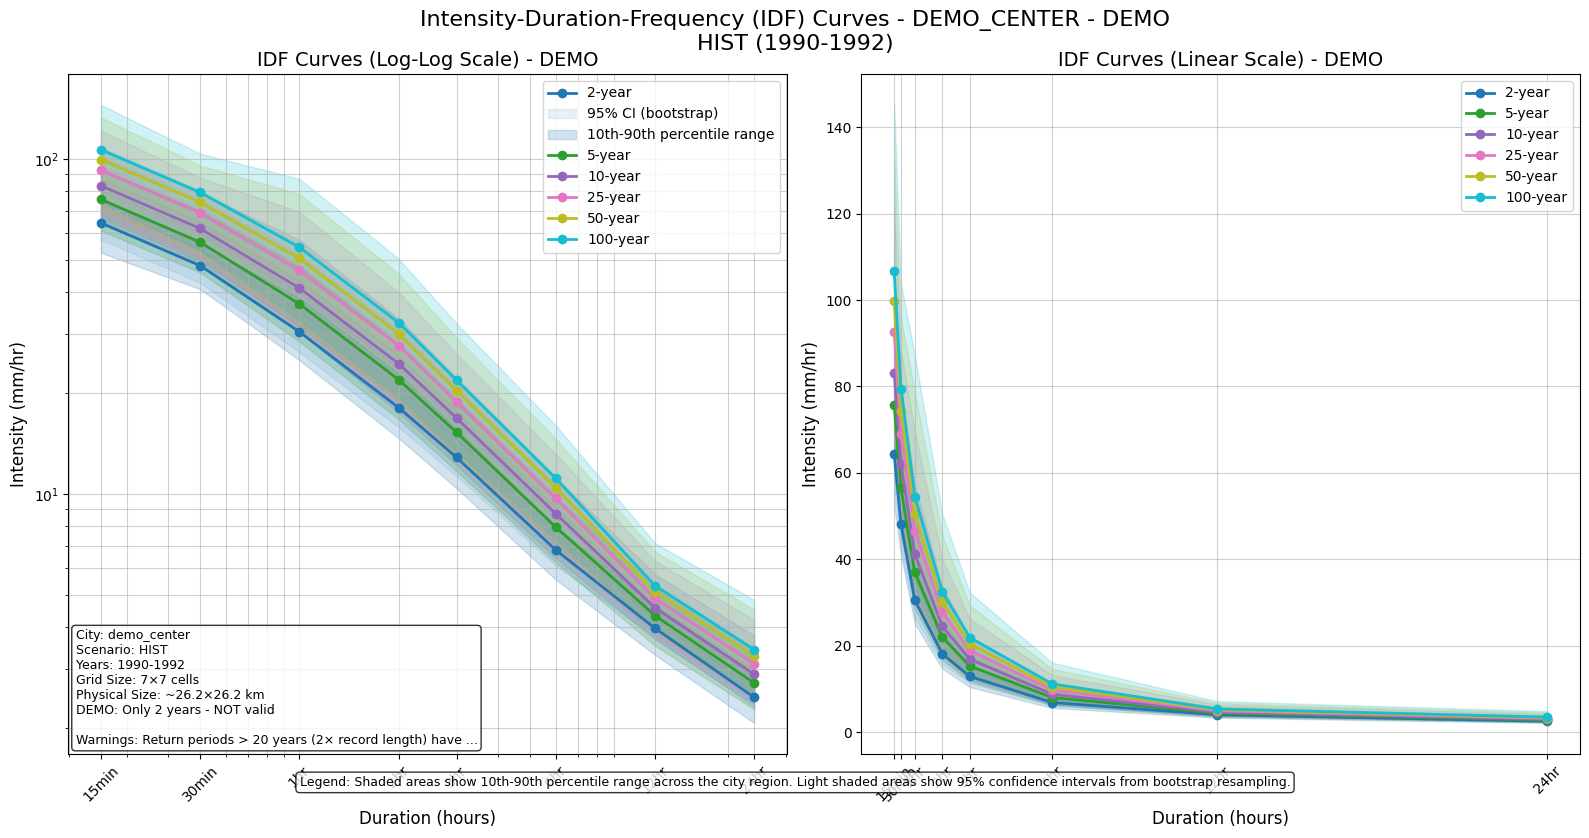

Generated IDF curve plot for demo_center
   Saved to: ./output/demo/idf/HIST/demo_center/


In [31]:
#Configuration for visualization

# Change these values to focus on different cities, etc.
VISUALIZATION_CITY = DEFAULT_CITY  # City to visualize
SHOW_CONFIDENCE_INTERVALS = True   # Whether to show confidence intervals
SHOW_SPATIAL_VARIABILITY = True    # Whether to show spatial variability range
SHOW_EXAMPLE_CELLS = False         # Whether to show individual cell curves




#Plot IDF Curves

def plot_idf_curves(idf_results, city_name, show_ci=True, show_spatial=True, show_cells=False):
    """
    Plot Intensity-Duration-Frequency (IDF) curves in both log-log and linear scales.
    
    DEMO VERSION: Same plotting logic.
    
    Parameters:
    -----------
    idf_results : dict
        Dictionary with city names as keys and IDF datasets as values
    city_name : str
        Name of the city to plot
    show_ci : bool
        Whether to show confidence intervals from bootstrap resampling
    show_spatial : bool
        Whether to show spatial variability range (10th-90th percentiles)
    show_cells : bool
        Whether to show example individual cell curves
    
    Returns:
    --------
    matplotlib.figure.Figure : Figure with IDF curve plots
    """
    if city_name not in idf_results:
        logger.error(f"No IDF data found for {city_name}")
        return None
    
    idf_data = idf_results[city_name]
    
    # Get dimension information
    lat_dim = idf_data.attrs.get('lat_dim', 'south_north')
    lon_dim = idf_data.attrs.get('lon_dim', 'west_east')
    
    # Get return periods and durations
    return_periods = idf_data.return_period.values
    durations = idf_data.duration.values
    duration_labels = idf_data.duration_label.values
    
    # Create figure with two subplots (log-log and linear)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Color map for different return periods
    colors = plt.cm.tab10(np.linspace(0, 1, len(return_periods)))
    
    # Plot 1: Log-log scale (traditional IDF curve)
    for i, rp in enumerate(return_periods):
        # Extract mean intensity for this return period
        if 'ensemble_mean' in idf_data:
            mean = idf_data.ensemble_mean[i, :].values
        else:
            logger.error("ensemble_mean not found in IDF data")
            return None
        
        # Plot the mean curve
        ax1.loglog(durations, mean, 'o-', color=colors[i], linewidth=2, label=f"{int(rp)}-year")
        
        # Plot confidence intervals from bootstrap if requested
        if show_ci and 'cell_ci_lower' in idf_data and 'cell_ci_upper' in idf_data:
            # Calculate average confidence intervals across all cells
            ci_lower = idf_data.cell_ci_lower[:, :, i, :].mean(dim=[lat_dim, lon_dim], skipna=True).values
            ci_upper = idf_data.cell_ci_upper[:, :, i, :].mean(dim=[lat_dim, lon_dim], skipna=True).values
            
            ax1.fill_between(durations, ci_lower, ci_upper, color=colors[i], alpha=0.1,
                            label=f"95% CI (bootstrap)" if i == 0 else "")
        
        # Plot spatial variability range if requested
        if show_spatial and 'ensemble_lower' in idf_data and 'ensemble_upper' in idf_data:
            lower = idf_data.ensemble_lower[i, :].values
            upper = idf_data.ensemble_upper[i, :].values
            
            ax1.fill_between(durations, lower, upper, color=colors[i], alpha=0.2,
                           label=f"10th-90th percentile range" if i == 0 else "")
        
        # Plot example individual cell curves if requested
        if show_cells and 'cell_intensity' in idf_data:
            # Get grid dimensions
            lat_size = idf_data.dims[lat_dim]
            lon_size = idf_data.dims[lon_dim]
            
            # Sample some cells systematically
            max_cells = 5  # Maximum number of cells to show
            lat_step = max(1, lat_size // (max_cells + 1))
            lon_step = max(1, lon_size // (max_cells + 1))
            
            for lat_idx in range(lat_step, lat_size, lat_step * 2):
                for lon_idx in range(lon_step, lon_size, lon_step * 2):
                    try:
                        # Get intensity for this cell
                        cell_intensity = idf_data.cell_intensity[lat_idx, lon_idx, i, :].values
                        
                        # Only plot if not all NaN
                        if not np.all(np.isnan(cell_intensity)):
                            ax1.loglog(durations, cell_intensity, '-', color=colors[i], 
                                      linewidth=0.5, alpha=0.3)
                    except (IndexError, KeyError):
                        continue
    
    # Configure log-log plot
    ax1.set_xlabel('Duration (hours)', fontsize=12)
    ax1.set_ylabel('Intensity (mm/hr)', fontsize=12)
    ax1.set_title('IDF Curves (Log-Log Scale) - DEMO', fontsize=14)
    ax1.grid(True, which="both", ls="-", alpha=0.6)
    ax1.set_xticks(durations)
    ax1.set_xticklabels(duration_labels, rotation=45)
    ax1.legend(loc='upper right')
    
    # Plot 2: Linear scale
    for i, rp in enumerate(return_periods):
        # Extract mean intensity for this return period
        if 'ensemble_mean' in idf_data:
            mean = idf_data.ensemble_mean[i, :].values
        else:
            logger.error("ensemble_mean not found in IDF data")
            return None
        
        # Plot the mean curve
        ax2.plot(durations, mean, 'o-', color=colors[i], linewidth=2, label=f"{int(rp)}-year")
        
        # Plot confidence intervals from bootstrap if requested
        if show_ci and 'cell_ci_lower' in idf_data and 'cell_ci_upper' in idf_data:
            # Calculate average confidence intervals across all cells
            ci_lower = idf_data.cell_ci_lower[:, :, i, :].mean(dim=[lat_dim, lon_dim], skipna=True).values
            ci_upper = idf_data.cell_ci_upper[:, :, i, :].mean(dim=[lat_dim, lon_dim], skipna=True).values
            
            ax2.fill_between(durations, ci_lower, ci_upper, color=colors[i], alpha=0.1)
        
        # Plot spatial variability range if requested
        if show_spatial and 'ensemble_lower' in idf_data and 'ensemble_upper' in idf_data:
            lower = idf_data.ensemble_lower[i, :].values
            upper = idf_data.ensemble_upper[i, :].values
            
            ax2.fill_between(durations, lower, upper, color=colors[i], alpha=0.2)
        
        # Plot example individual cell curves if requested
        if show_cells and 'cell_intensity' in idf_data:
            # Use the same sampled cells as in the log-log plot
            lat_size = idf_data.dims[lat_dim]
            lon_size = idf_data.dims[lon_dim]
            
            # Sample some cells systematically
            max_cells = 5  # Maximum number of cells to show
            lat_step = max(1, lat_size // (max_cells + 1))
            lon_step = max(1, lon_size // (max_cells + 1))
            
            for lat_idx in range(lat_step, lat_size, lat_step * 2):
                for lon_idx in range(lon_step, lon_size, lon_step * 2):
                    try:
                        # Get intensity for this cell
                        cell_intensity = idf_data.cell_intensity[lat_idx, lon_idx, i, :].values
                        
                        # Only plot if not all NaN
                        if not np.all(np.isnan(cell_intensity)):
                            ax2.plot(durations, cell_intensity, '-', color=colors[i], 
                                   linewidth=0.5, alpha=0.3)
                    except (IndexError, KeyError):
                        continue
    
    # Configure linear plot
    ax2.set_xlabel('Duration (hours)', fontsize=12)
    ax2.set_ylabel('Intensity (mm/hr)', fontsize=12)
    ax2.set_title('IDF Curves (Linear Scale) - DEMO', fontsize=14)
    ax2.grid(True, alpha=0.6)
    ax2.set_xticks(durations)
    ax2.set_xticklabels(duration_labels, rotation=45)
    ax2.legend(loc='upper right')
    
    # Add information box
    info_text = (f"City: {city_name}\n"
                f"Scenario: {SCENARIO}\n"
                f"Years: {HYDRO_YEAR_START}-{HYDRO_YEAR_END}\n"
                f"Grid Size: {idf_data.dims[lat_dim]}×{idf_data.dims[lon_dim]} cells\n"
                f"Physical Size: ~{idf_data.dims[lat_dim]*3.75:.1f}×{idf_data.dims[lon_dim]*3.75:.1f} km\n"
                f"DEMO: Only 2 years - NOT valid")
    
    # Add warnings if any
    if 'warnings' in idf_data.attrs and idf_data.attrs['warnings'] != 'None':
        info_text += f"\n\nWarnings: {idf_data.attrs['warnings'][:50]}..."
    
    ax1.text(0.01, 0.01, info_text, transform=ax1.transAxes, fontsize=9,
            va='bottom', ha='left', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Add subtitle with legend explanation
    legend_text = "Legend:"
    if show_spatial:
        legend_text += " Shaded areas show 10th-90th percentile range across the city region."
    if show_ci:
        legend_text += " Light shaded areas show 95% confidence intervals from bootstrap resampling."
    if show_cells:
        legend_text += " Thin lines show individual grid cell curves."
    
    plt.figtext(0.5, 0.01, legend_text, ha='center', fontsize=9, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Add overall title
    plt.suptitle(f'Intensity-Duration-Frequency (IDF) Curves - {city_name.upper()} - DEMO\n{SCENARIO} ({HYDRO_YEAR_START}-{HYDRO_YEAR_END})', 
                fontsize=16)
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.9, bottom=0.05)  # Make room for title and legend explanation
    
    # Save the figure
    city_output_dir = f"{OUTPUT_DIR}/{city_name}"
    fig_path = f"{city_output_dir}/idf_curves_{SCENARIO}_{city_name}.png"
    fig.savefig(fig_path, dpi=300, bbox_inches='tight')
    logger.info(f"Saved IDF curves to {fig_path}")
    
    return fig


# Generate IDF curve plots for the visualization city
if 'idf_results' in locals() and idf_results and VISUALIZATION_CITY in idf_results:
    logger.info(f"Generating IDF curve visualizations for {VISUALIZATION_CITY}")
    
    # Plot IDF curves
    try:
        idf_fig = plot_idf_curves(idf_results, VISUALIZATION_CITY, 
                                show_ci=SHOW_CONFIDENCE_INTERVALS,
                                show_spatial=SHOW_SPATIAL_VARIABILITY,
                                show_cells=SHOW_EXAMPLE_CELLS)
        plt.show()
        
        print(f"Generated IDF curve plot for {VISUALIZATION_CITY}")
        print(f"   Saved to: {OUTPUT_DIR}/{VISUALIZATION_CITY}/")
    except Exception as e:
        logger.error(f"Error creating IDF curve plot: {str(e)}")
        print(f"Error creating IDF curve plot: {str(e)}")
else:
    print("No IDF data available for visualization")



2026-02-09 23:27:09,143 - INFO - Generating return period curve visualizations for demo_center
2026-02-09 23:27:11,031 - INFO - Saved return period curves to ./output/demo/idf/HIST/demo_center/return_period_curves_HIST_demo_center.png


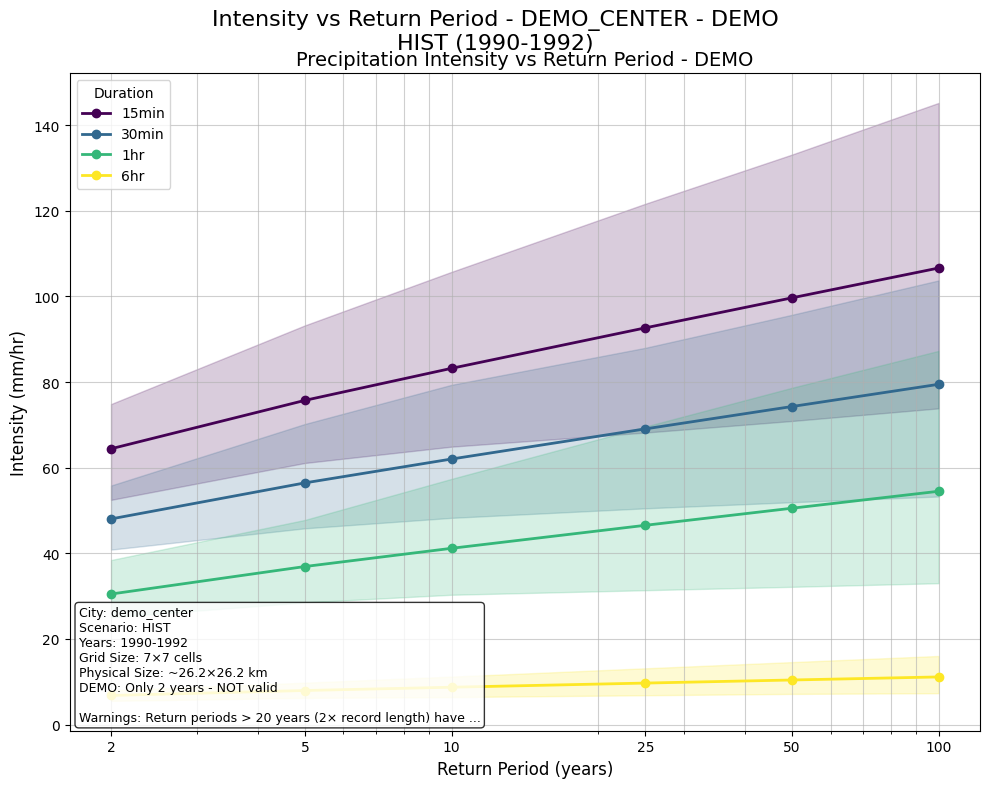

Generated return period curve plot for demo_center


In [32]:
# Return Period Visualizations

def plot_return_period_curves(idf_results, city_name, duration_indices=None, show_spatial=True, show_cells=False):
    """
    Plot precipitation intensity as a function of return period for selected durations.
    
    DEMO VERSION: Same plotting logic.
    
    Parameters:
    -----------
    idf_results : dict
        Dictionary with city names as keys and IDF datasets as values
    city_name : str
        Name of the city to plot
    duration_indices : list, optional
        List of duration indices to include, defaults to [0, 1, 3, 6] (15min, 30min, 1hr, 6hr)
    show_spatial : bool
        Whether to show spatial variability range (10th-90th percentiles)
    show_cells : bool
        Whether to show example individual cell curves
    
    Returns:
    --------
    matplotlib.figure.Figure : Figure with return period curves
    """
    if city_name not in idf_results:
        logger.error(f"No IDF data found for {city_name}")
        return None
    
    idf_data = idf_results[city_name]
    
    # Get dimension information
    lat_dim = idf_data.attrs.get('lat_dim', 'south_north')
    lon_dim = idf_data.attrs.get('lon_dim', 'west_east')
    
    # Get return periods and durations
    return_periods = idf_data.return_period.values
    durations = idf_data.duration.values
    duration_labels = idf_data.duration_label.values
    
    # Use default durations if not specified
    if duration_indices is None:
        # Try to select 15min, 30min, 1hr, and 6hr durations
        duration_indices = []
        duration_names = ["15min", "30min", "1hr", "6hr"]
        
        for name in duration_names:
            try:
                idx = list(duration_labels).index(name)
                duration_indices.append(idx)
            except ValueError:
                # Duration not found, try to select based on position
                pass
        
        # If we couldn't find any, use first, second, middle and last
        if not duration_indices:
            if len(durations) >= 4:
                duration_indices = [0, 1, len(durations)//2, -1]
            else:
                duration_indices = list(range(len(durations)))
    
    # Ensure indices are within bounds
    duration_indices = [idx for idx in duration_indices if idx < len(durations)]
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Color map for different durations
    colors = plt.cm.viridis(np.linspace(0, 1, len(duration_indices)))
    
    # Plot intensity vs return period for each selected duration
    for i, dur_idx in enumerate(duration_indices):
        dur_label = duration_labels[dur_idx]
        
        # Extract mean intensity for all return periods
        if 'ensemble_mean' in idf_data:
            mean = idf_data.ensemble_mean[:, dur_idx].values
        else:
            logger.error("ensemble_mean not found in IDF data")
            return None
        
        # Plot the mean curve with semi-log scale (log x-axis)
        ax.semilogx(return_periods, mean, 'o-', color=colors[i], linewidth=2, label=f"{dur_label}")
        
        # Plot spatial variability range if requested
        if show_spatial and 'ensemble_lower' in idf_data and 'ensemble_upper' in idf_data:
            lower = idf_data.ensemble_lower[:, dur_idx].values
            upper = idf_data.ensemble_upper[:, dur_idx].values
            
            ax.fill_between(return_periods, lower, upper, color=colors[i], alpha=0.2)
        
        # Plot example individual cell curves if requested
        if show_cells and 'cell_intensity' in idf_data:
            # Get grid dimensions
            lat_size = idf_data.dims[lat_dim]
            lon_size = idf_data.dims[lon_dim]
            
            # Sample some cells systematically
            max_cells = 5  # Maximum number of cells to show
            lat_step = max(1, lat_size // (max_cells + 1))
            lon_step = max(1, lon_size // (max_cells + 1))
            
            for lat_idx in range(lat_step, lat_size, lat_step * 2):
                for lon_idx in range(lon_step, lon_size, lon_step * 2):
                    try:
                        # Get intensity for this cell
                        cell_intensity = idf_data.cell_intensity[lat_idx, lon_idx, :, dur_idx].values
                        
                        # Only plot if not all NaN
                        if not np.all(np.isnan(cell_intensity)):
                            ax.semilogx(return_periods, cell_intensity, '-', color=colors[i], 
                                      linewidth=0.5, alpha=0.3)
                    except (IndexError, KeyError):
                        continue
    
    # Configure plot
    ax.set_xlabel('Return Period (years)', fontsize=12)
    ax.set_ylabel('Intensity (mm/hr)', fontsize=12)
    ax.set_title('Precipitation Intensity vs Return Period - DEMO', fontsize=14)
    ax.grid(True, which="both", ls="-", alpha=0.6)
    
    # Set x-axis to show return periods at specific points
    ax.set_xticks(return_periods)
    ax.set_xticklabels([str(int(rp)) for rp in return_periods])
    
    # Add legend
    ax.legend(loc='upper left', title="Duration")
    
    # Add information box
    info_text = (f"City: {city_name}\n"
                f"Scenario: {SCENARIO}\n"
                f"Years: {HYDRO_YEAR_START}-{HYDRO_YEAR_END}\n"
                f"Grid Size: {idf_data.dims[lat_dim]}×{idf_data.dims[lon_dim]} cells\n"
                f"Physical Size: ~{idf_data.dims[lat_dim]*3.75:.1f}×{idf_data.dims[lon_dim]*3.75:.1f} km\n"
                f"DEMO: Only 2 years - NOT valid")
    
    # Add warnings if any
    if 'warnings' in idf_data.attrs and idf_data.attrs['warnings'] != 'None':
        info_text += f"\n\nWarnings: {idf_data.attrs['warnings'][:50]}..."
    
    ax.text(0.01, 0.01, info_text, transform=ax.transAxes, fontsize=9,
           va='bottom', ha='left', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Add overall title
    plt.suptitle(f'Intensity vs Return Period - {city_name.upper()} - DEMO\n{SCENARIO} ({HYDRO_YEAR_START}-{HYDRO_YEAR_END})', 
                fontsize=16)
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.9)  # Make room for title
    
    # Save the figure
    city_output_dir = f"{OUTPUT_DIR}/{city_name}"
    fig_path = f"{city_output_dir}/return_period_curves_{SCENARIO}_{city_name}.png"
    fig.savefig(fig_path, dpi=300, bbox_inches='tight')
    logger.info(f"Saved return period curves to {fig_path}")
    
    return fig


# Generate return period curves for the visualization city
if 'idf_results' in locals() and idf_results and VISUALIZATION_CITY in idf_results:
    logger.info(f"Generating return period curve visualizations for {VISUALIZATION_CITY}")
    
    try:
        rp_fig = plot_return_period_curves(idf_results, VISUALIZATION_CITY,
                                         show_spatial=SHOW_SPATIAL_VARIABILITY,
                                         show_cells=SHOW_EXAMPLE_CELLS)
        plt.show()
        
        print(f"Generated return period curve plot for {VISUALIZATION_CITY}")
    except Exception as e:
        logger.error(f"Error creating return period curve plot: {str(e)}")
        print(f"Error creating return period curve plot: {str(e)}")




In [33]:
# Cell 16: Export IDF Tables

def create_idf_table(idf_results, city_name, include_ci=True):
    """
    Create a formatted table of IDF values suitable for engineering applications.
    
    DEMO VERSION: Same table creation logic.
    
    Parameters:
    -----------
    idf_results : dict
        Dictionary with city names as keys and IDF datasets as values
    city_name : str
        Name of the city to tabulate
    include_ci : bool
        Whether to include confidence intervals in the table
    
    Returns:
    --------
    pandas.DataFrame : DataFrame containing the IDF table
    """
    if city_name not in idf_results:
        logger.error(f"No IDF data found for {city_name}")
        return None
    
    idf_data = idf_results[city_name]
    
    # Get return periods and durations
    return_periods = [int(rp) for rp in idf_data.return_period.values]
    durations = idf_data.duration.values
    duration_labels = idf_data.duration_label.values
    
    # Create a multi-level index DataFrame
    import pandas as pd
    
    # Create empty list to store rows
    rows = []
    
    # Add each duration as a row
    for dur_idx, dur_label in enumerate(duration_labels):
        row_data = {'Duration': dur_label}
        
        # Add mean intensity for each return period
        for rp_idx, rp in enumerate(return_periods):
            intensity = idf_data.ensemble_mean[rp_idx, dur_idx].item()
            
            if include_ci and 'ensemble_lower' in idf_data.data_vars and 'ensemble_upper' in idf_data.data_vars:
                lower = idf_data.ensemble_lower[rp_idx, dur_idx].item()
                upper = idf_data.ensemble_upper[rp_idx, dur_idx].item()
                
                # Calculate half-width of the CI
                half_width = (upper - lower) / 2
                
                # Format with confidence interval
                row_data[f'{rp}-year'] = f"{intensity:.2f} ± {half_width:.2f}"
            else:
                # Format just the intensity
                row_data[f'{rp}-year'] = f"{intensity:.2f}"
        
        # Add the row
        rows.append(row_data)
    
    # Create DataFrame
    df = pd.DataFrame(rows)
    
    # Set Duration as index
    df.set_index('Duration', inplace=True)
    
    # Add metadata
    df.attrs['scenario'] = SCENARIO
    df.attrs['city_name'] = city_name
    df.attrs['year_range'] = f"{HYDRO_YEAR_START}-{HYDRO_YEAR_END}"
    df.attrs['units'] = "mm/hr"
    df.attrs['demo_warning'] = "DEMO: Only 2 years - NOT statistically valid"
    if include_ci:
        df.attrs['notes'] = "Values shown as mean ± half-width of 10th-90th percentile range"
    
    return df


def export_idf_tables(idf_results, city_name=None, format='csv'):
    """
    Export IDF tables for all cities or a specific city.
    
    DEMO VERSION: Same export logic with demo warning.
    
    Parameters:
    -----------
    idf_results : dict
        Dictionary with city names as keys and IDF datasets as values
    city_name : str, optional
        Name of the city to export, exports all cities if None
    format : str
        Format for export: 'csv', 'excel', or 'latex'
    
    Returns:
    --------
    dict : Dictionary of DataFrames with city names as keys
    """
    import pandas as pd
    
    # Cities to process
    cities = [city_name] if city_name else list(idf_results.keys())
    
    # Check if cities exist in results
    cities = [city for city in cities if city in idf_results]
    
    if not cities:
        logger.error(f"No valid cities found in IDF results")
        return None
    
    # Create tables for each city
    tables = {}
    
    for city in cities:
        logger.info(f"Creating IDF table for {city}")
        
        # Create a table with and without confidence intervals
        df = create_idf_table(idf_results, city, include_ci=False)
        df_with_ci = create_idf_table(idf_results, city, include_ci=True)
        
        if df is not None:
            tables[city] = df
            
            # Export based on requested format
            city_output_dir = f"{OUTPUT_DIR}/{city}"
            
            if format == 'csv' or format == 'all':
                csv_path = f"{city_output_dir}/idf_table_{SCENARIO}_{city}.csv"
                df.to_csv(csv_path)
                logger.info(f"Saved CSV table to {csv_path}")
                
                csv_ci_path = f"{city_output_dir}/idf_table_with_ci_{SCENARIO}_{city}.csv"
                df_with_ci.to_csv(csv_ci_path)
                logger.info(f"Saved CSV table with CI to {csv_ci_path}")
            
            if format == 'excel' or format == 'all':
                excel_path = f"{city_output_dir}/idf_table_{SCENARIO}_{city}.xlsx"
                with pd.ExcelWriter(excel_path) as writer:
                    df.to_excel(writer, sheet_name='IDF Values')
                    df_with_ci.to_excel(writer, sheet_name='IDF Values with CI')
                    
                    # Write metadata
                    metadata = pd.DataFrame([
                        ['Scenario', SCENARIO],
                        ['City', city],
                        ['Years', f"{HYDRO_YEAR_START}-{HYDRO_YEAR_END}"],
                        ['Units', 'mm/hr'],
                        ['Created', datetime.now().strftime('%Y-%m-%d %H:%M:%S')],
                        ['WARNING', 'DEMO: Only 2 years - NOT statistically valid']
                    ], columns=['Property', 'Value'])
                    
                    metadata.to_excel(writer, sheet_name='Metadata', index=False)
                
                logger.info(f"Saved Excel table to {excel_path}")
            
            if format == 'latex' or format == 'all':
                latex_path = f"{city_output_dir}/idf_table_{SCENARIO}_{city}.tex"
                with open(latex_path, 'w') as f:
                    f.write(f"% IDF Table for {city} - {SCENARIO} ({HYDRO_YEAR_START}-{HYDRO_YEAR_END})\n")
                    f.write("% Units: mm/hr\n")
                    f.write("% WARNING: DEMO - Only 2 years - NOT statistically valid\n\n")
                    f.write(df.to_latex(caption=f"IDF Table for {city} - {SCENARIO} (DEMO)"))
                
                logger.info(f"Saved LaTeX table to {latex_path}")
    
    return tables


# Generate tables for all cities
if 'idf_results' in locals() and idf_results:
    logger.info("Exporting IDF tables for all cities")
    tables = export_idf_tables(idf_results, format='all')
    
    # Print example of the table for the visualization city
    if VISUALIZATION_CITY in tables:
        print(f"\n=== IDF TABLE FOR {VISUALIZATION_CITY.upper()} (DEMO) ===")
        print(f"Scenario: {SCENARIO}, Years: {HYDRO_YEAR_START}-{HYDRO_YEAR_END}")
        print(f"Units: mm/hr\n")
        print("WARNING: Only 2 years of data - NOT statistically valid\n")
        print(tables[VISUALIZATION_CITY])
        
        print("\nTable files have been saved to:")
        print(f"  - CSV: {OUTPUT_DIR}/{VISUALIZATION_CITY}/idf_table_{SCENARIO}_{VISUALIZATION_CITY}.csv")
        print(f"  - Excel: {OUTPUT_DIR}/{VISUALIZATION_CITY}/idf_table_{SCENARIO}_{VISUALIZATION_CITY}.xlsx")
        print(f"  - LaTeX: {OUTPUT_DIR}/{VISUALIZATION_CITY}/idf_table_{SCENARIO}_{VISUALIZATION_CITY}.tex")
else:
    print("No IDF data available for summary table")


2026-02-09 23:27:12,165 - INFO - Exporting IDF tables for all cities
2026-02-09 23:27:12,168 - INFO - Creating IDF table for demo_north
2026-02-09 23:27:12,246 - INFO - Saved CSV table to ./output/demo/idf/HIST/demo_north/idf_table_HIST_demo_north.csv
2026-02-09 23:27:12,250 - INFO - Saved CSV table with CI to ./output/demo/idf/HIST/demo_north/idf_table_with_ci_HIST_demo_north.csv
2026-02-09 23:27:12,554 - INFO - Saved Excel table to ./output/demo/idf/HIST/demo_north/idf_table_HIST_demo_north.xlsx
2026-02-09 23:27:12,573 - INFO - Saved LaTeX table to ./output/demo/idf/HIST/demo_north/idf_table_HIST_demo_north.tex
2026-02-09 23:27:12,581 - INFO - Creating IDF table for demo_center
2026-02-09 23:27:12,659 - INFO - Saved CSV table to ./output/demo/idf/HIST/demo_center/idf_table_HIST_demo_center.csv
2026-02-09 23:27:12,663 - INFO - Saved CSV table with CI to ./output/demo/idf/HIST/demo_center/idf_table_with_ci_HIST_demo_center.csv
2026-02-09 23:27:12,707 - INFO - Saved Excel table to ./out

/tmp/ipykernel_14893/1844717795.py:163: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  f.write(df.to_latex(caption=f"IDF Table for {city} - {SCENARIO} (DEMO)"))
/tmp/ipykernel_14893/1844717795.py:163: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  f.write(df.to_latex(caption=f"IDF Table for {city} - {SCENARIO} (DEMO)"))


2026-02-09 23:27:12,805 - INFO - Saved CSV table to ./output/demo/idf/HIST/demo_south/idf_table_HIST_demo_south.csv
2026-02-09 23:27:12,810 - INFO - Saved CSV table with CI to ./output/demo/idf/HIST/demo_south/idf_table_with_ci_HIST_demo_south.csv
2026-02-09 23:27:12,858 - INFO - Saved Excel table to ./output/demo/idf/HIST/demo_south/idf_table_HIST_demo_south.xlsx
2026-02-09 23:27:12,882 - INFO - Saved LaTeX table to ./output/demo/idf/HIST/demo_south/idf_table_HIST_demo_south.tex

=== IDF TABLE FOR DEMO_CENTER (DEMO) ===
Scenario: HIST, Years: 1990-1992
Units: mm/hr


         2-year 5-year 10-year 25-year 50-year 100-year
Duration                                               
15min     64.43  75.73   83.21   92.67   99.68   106.64
30min     48.03  56.45   62.03   69.07   74.29    79.48
1hr       30.49  36.92   41.17   46.55   50.54    54.49
2hr       18.11  21.95   24.49   27.70   30.09    32.46
3hr       12.85  15.25   16.85   18.86   20.35    21.84
6hr        6.80   7.96    8.72   

/tmp/ipykernel_14893/1844717795.py:163: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  f.write(df.to_latex(caption=f"IDF Table for {city} - {SCENARIO} (DEMO)"))


In [34]:
# ============================================================================
# DIAGNOSTIC: Check annual maxima files
# ============================================================================

print("\n=== CHECKING ANNUAL MAXIMA FILES ===")

for city_name in ["demo_center"]:
    for year in [1990, 1991]:
        year_file = f"{OUTPUT_DIR}/{city_name}/annual_maxima_HIST_{year}-{year+1}_{city_name}_{VERSION_TAG}.nc"
        
        if os.path.exists(year_file):
            print(f"\n{city_name}, {year}-{year+1}:")
            ds = xr.open_dataset(year_file)
            
            # Check each duration
            for var in ds.data_vars:
                if var.startswith("max_intensity_"):
                    data = ds[var].values
                    print(f"  {var}:")
                    print(f"    Shape: {data.shape}")
                    print(f"    Max value: {np.nanmax(data)}")
                    print(f"    Min value: {np.nanmin(data)}")
                    print(f"    Non-NaN count: {np.sum(~np.isnan(data))} / {data.size}")
                    print(f"    Sample values: {data[~np.isnan(data)][:5]}")
            
            ds.close()
        else:
            print(f"\nERROR: File not found: {year_file}")


=== CHECKING ANNUAL MAXIMA FILES ===

demo_center, 1990-1991:
  max_intensity_15min:
    Shape: (7, 7)
    Max value: 103.699951171875
    Min value: 33.8873291015625
    Non-NaN count: 49 / 49
    Sample values: [97.927734 67.76294  89.37256  71.642944 63.001343]
  max_intensity_30min:
    Shape: (7, 7)
    Max value: 76.7225341796875
    Min value: 25.48834228515625
    Non-NaN count: 49 / 49
    Sample values: [72.28046  52.9115   70.906006 50.150146 39.189575]
  max_intensity_1hr:
    Shape: (7, 7)
    Max value: 53.1103515625
    Min value: 14.66229248046875
    Non-NaN count: 49 / 49
    Sample values: [43.875305 33.567688 41.020782 32.56418  27.389465]
  max_intensity_2hr:
    Shape: (7, 7)
    Max value: 30.510269165039062
    Min value: 8.936492919921875
    Non-NaN count: 49 / 49
    Sample values: [22.043701 18.082077 21.681503 17.524506 17.134247]
  max_intensity_3hr:
    Shape: (7, 7)
    Max value: 20.44185447692871
    Min value: 6.196918487548828
    Non-NaN count: 49 